***AI used [1]***

In [8]:
# ===== Setup for Windows + GPU =====

import os
import torch

# Detect GPU
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print("YOLO will run on:", device)

# Create project folders
BASE_DIR = "ImageProcessing_FinalProject"
os.makedirs(BASE_DIR, exist_ok=True)

print("Project folder:", os.path.abspath(BASE_DIR))

YOLO will run on: cuda:0
Project folder: c:\Users\Yuval\Desktop\Rupin\Year 4\עיבוד תמונה וראייה ממוחשבת\final\ImageProcessing_FinalProject


## Installs and imports

In [9]:
import os
import zipfile
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

from io import BytesIO
from PIL import Image
from collections import defaultdict, Counter
from tqdm import tqdm


# 3.

## 3.1 - Loading the COCO validation annotations

In this section, we download the COCO 2017 annotation archive if it is not already available locally, extract the validation annotations, and initialize the COCO API object.


##### COCO initialization

In [10]:
# Download and extract COCO annotations

url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"

os.makedirs("annotations", exist_ok=True)

zip_path = "annotations/annotations_trainval2017.zip"

if not os.path.exists(zip_path):
    r = requests.get(url)
    open(zip_path, "wb").write(r.content)

if not os.path.exists("annotations/annotations"):
    with zipfile.ZipFile(zip_path) as z:
        z.extractall("annotations")
        
annotation_file_path = "annotations/annotations/instances_val2017.json"

In [11]:
coco = COCO(annotation_file_path)

cats = coco.loadCats(coco.getCatIds())
cat_id_to_name = {cat["id"]: cat["name"] for cat in cats}

img_ids = coco.getImgIds()

print("Number of validation images:", len(img_ids))
print("Number of categories:", len(cats))
print("First 10 category names:", list(cat_id_to_name.values())[:10])

loading annotations into memory...
Done (t=0.53s)
creating index...
index created!
Number of validation images: 5000
Number of categories: 80
First 10 category names: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


## 3.2 - Visual inspection of sample images

We randomly select several images from the COCO validation set and display their ground-truth annotations.

In [98]:
def show_coco_image_with_gt(coco, img_id, cat_id_to_name, box_color='red', timeout=30):
    img_info = coco.loadImgs(img_id)[0]
    img_url = img_info["coco_url"]

    response = requests.get(img_url, timeout=timeout)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content)).convert("RGB")

    ann_ids = coco.getAnnIds(imgIds=[img_id])
    anns = coco.loadAnns(ann_ids)

    plt.figure(figsize=(12, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"COCO image {img_info['file_name']} with ground truth")

    for ann in anns:
        x, y, w, h = ann["bbox"]
        rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor=box_color, linewidth=2)
        plt.gca().add_patch(rect)

        cat_name = cat_id_to_name.get(ann["category_id"], "unknown")
        plt.text(x, y - 5, cat_name, {'color': box_color, 'fontsize': 12, 'bbox': {'color': 'white', 'pad': 0}})

    plt.show()

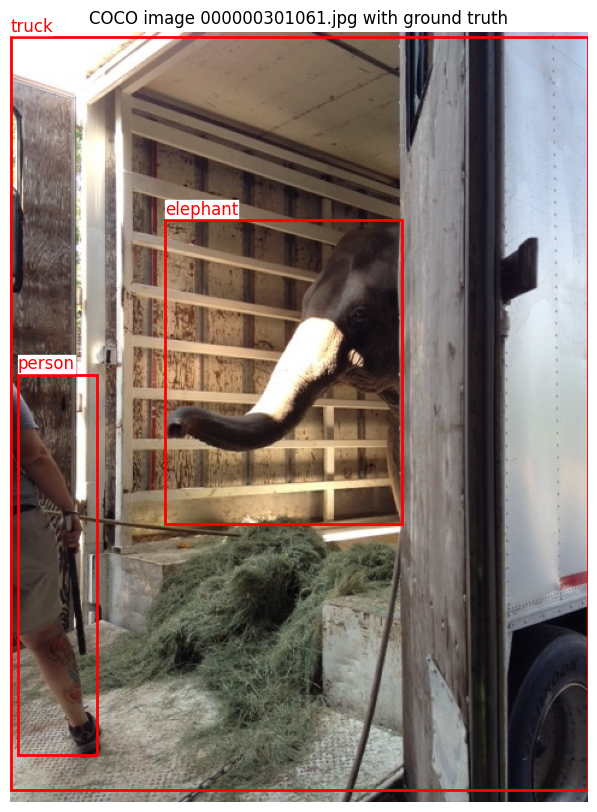

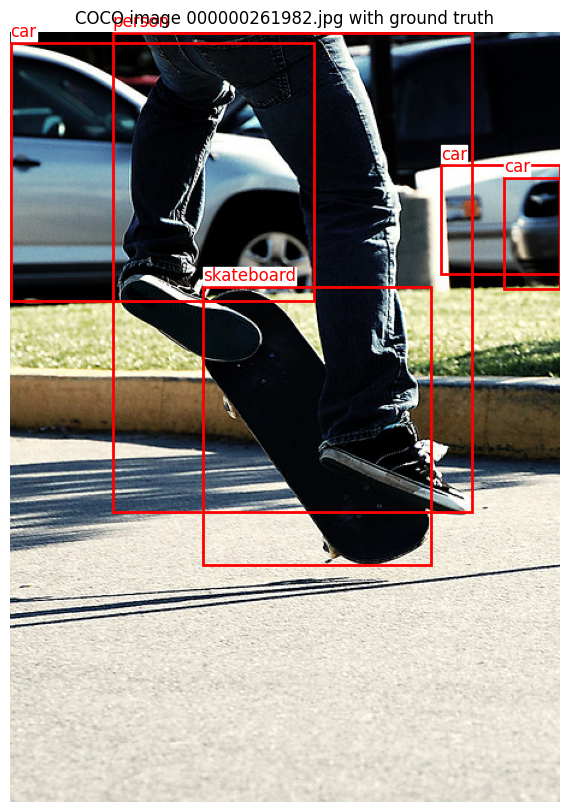

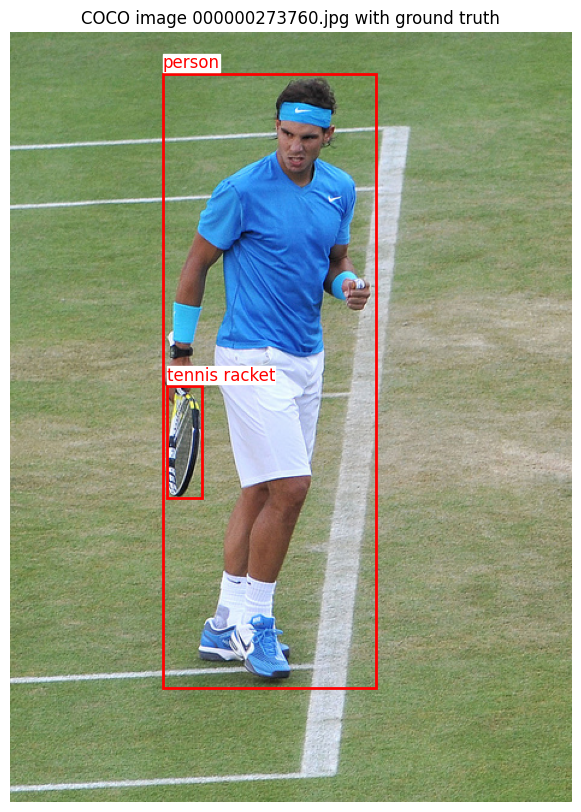

In [13]:
random.seed(42)
selected_img_ids = random.sample(img_ids, 3)

for img_id in selected_img_ids:
    show_coco_image_with_gt(coco, img_id, cat_id_to_name)

We randomly selected three images from the validation set and visualized their ground-truth bounding boxes together with their category labels.

This step confirms that the COCO annotations were loaded correctly and demonstrates the variability of the dataset in terms of object count, object scale, and category composition.

## 3.3 - Exploratory Data Analysis (EDA)

We perform an exploratory data analysis of the COCO validation dataset.

The goal of this analysis is to understand the dataset structure and characteristics, including:

- number of images in the dataset
- total number of objects
- average and median number of objects per image
- distribution of object categories
- distribution of bounding-box sizes
- size of objects within images

***AI used [2]***

##### DataFrame creation

In [14]:
# Create a DataFrame with annotation details for all images

rows = []

for img_id in img_ids:
    img = coco.loadImgs(img_id)[0]
    anns = coco.loadAnns(coco.getAnnIds(imgIds=[img_id]))

    for ann in anns:
        x, y, w, h = ann["bbox"]
        area = w * h

        rows.append({
            "image_id": img_id,
            "image_width": img["width"],
            "image_height": img["height"],
            "num_objects_in_image": len(anns),
            "category_id": ann["category_id"],
            "category_name": cat_id_to_name[ann["category_id"]],
            "bbox_x": x,
            "bbox_y": y,
            "bbox_w": w,
            "bbox_h": h,
            "bbox_area": area,
            "bbox_relative_area": area / (img["width"] * img["height"])
        })

df_annotations = pd.DataFrame(rows)

df_annotations.head()

,image_id,image_width,image_height,num_objects_in_image,category_id,category_name,bbox_x,bbox_y,bbox_w,bbox_h,bbox_area,bbox_relative_area
0,397133,640,427,19,44,bottle,217.62,240.54,38.99,57.75,2251.6725,0.008239
1,397133,640,427,19,67,dining table,1.00,240.24,346.63,186.76,64736.6188,0.236888
2,397133,640,427,19,1,person,388.66,69.92,109.41,277.62,30374.4042,0.111148
3,397133,640,427,19,49,knife,135.57,249.43,22.32,28.79,642.5928,0.002351
4,397133,640,427,19,51,bowl,31.28,344.00,68.12,40.83,2781.3396,0.010178


In [ ]:
num_images = len(img_ids)
num_objects = len(df_annotations)

objects_per_image = df_annotations.groupby("image_id").size()

mean_objects = objects_per_image.mean()
median_objects = objects_per_image.median()

num_categories = df_annotations["category_name"].nunique()

print("Dataset Statistics")
print("------------------")
print("Number of images:", num_images)
print("Total annotated objects:", num_objects)
print("Number of categories:", num_categories)
print("Average objects per image:", round(mean_objects,2))
print("Median objects per image:", median_objects)

print("\nObject Size Statistics")
print("----------------------")
print("Mean object relative area:", round(df_annotations["bbox_relative_area"].mean()*100, 3), "%")
print("Median object relative area:", round(df_annotations["bbox_relative_area"].median()*100, 3), "%")
print("Smallest object:", round(df_annotations["bbox_relative_area"].min()*100, 3), "%")
print("Largest object:", round(df_annotations["bbox_relative_area"].max()*100, 3), "%")


Dataset Statistics
------------------
Number of images: 5000
Total annotated objects: 36781
Number of categories: 80
Average objects per image: 7.43
Median objects per image: 4.0

Object Size Statistics
----------------------
Mean object relative area: 7.742441920569538 %
Median object relative area: 1.2270499999999998 %
Smallest object: 0.0008181640625 %
Largest object: 100.0 %


The dataset contains **5,000 images** and **36,781 annotated objects** across **80 categories**. Images contain on average **7.43 objects** (median 4), indicating that some images are much more crowded than others. Most objects are relatively **small compared to the image size**, as shown by the low median relative area (1.23%), while a few very large objects increase the average size.


##### Distribution of Objects per Image

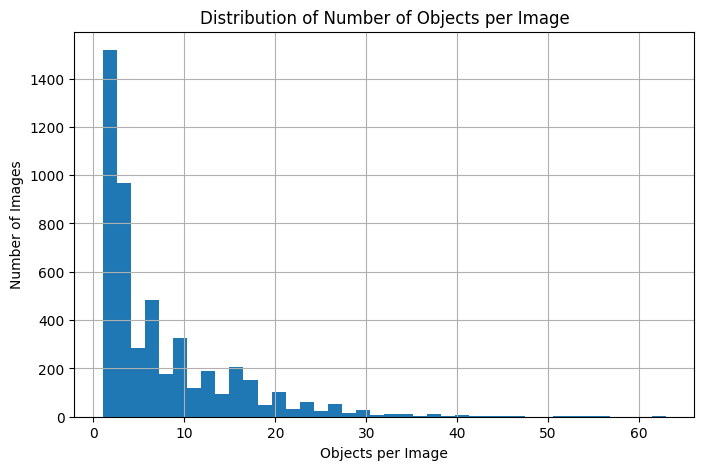

In [16]:
plt.figure(figsize=(8,5))
objects_per_image.hist(bins=40)

plt.title("Distribution of Number of Objects per Image")
plt.xlabel("Objects per Image")
plt.ylabel("Number of Images")

plt.show()

The distribution shows that **most images contain a small number of objects**, typically between **1 and 5**. As the number of objects per image increases, the frequency drops significantly, creating a **right-skewed distribution**. A small number of images contain many objects (20 or more), indicating that the dataset includes both simple scenes and more complex, crowded images.


##### Category Frequency

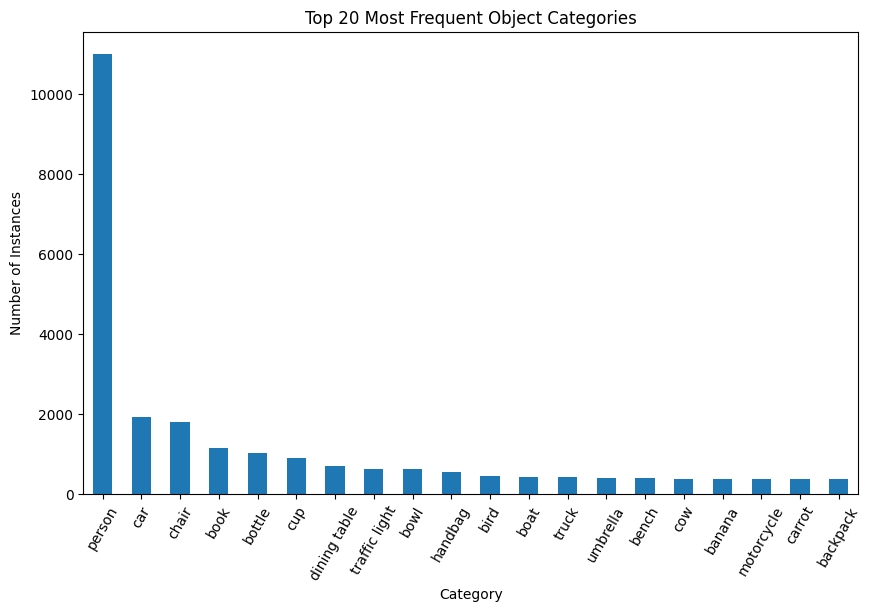

In [17]:
category_counts = df_annotations["category_name"].value_counts()

plt.figure(figsize=(10,6))

category_counts.head(20).plot(kind="bar")

plt.title("Top 20 Most Frequent Object Categories")
plt.ylabel("Number of Instances")
plt.xlabel("Category")

plt.xticks(rotation=60)

plt.show()

The category distribution is **highly imbalanced**. The class **person** appears far more frequently than any other category, while most other objects such as cars, chairs, and bottles appear much less often. This indicates that the dataset is dominated by a few common categories, while many classes occur relatively rarely.


##### Bounding Box Size Distribution

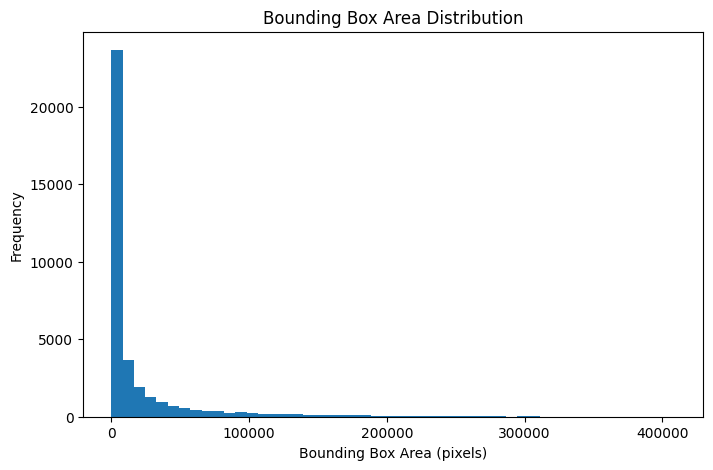

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df_annotations["bbox_area"], bins=50)

plt.title("Bounding Box Area Distribution")
plt.xlabel("Bounding Box Area (pixels)")
plt.ylabel("Frequency")

plt.show()

The distribution shows that **most bounding boxes are small**, with a high concentration of objects having low pixel areas. As the bounding box area increases, the frequency decreases sharply, resulting in a **right-skewed distribution**. This indicates that the dataset contains many small objects and relatively few large ones.


##### Relative Bounding Box Size

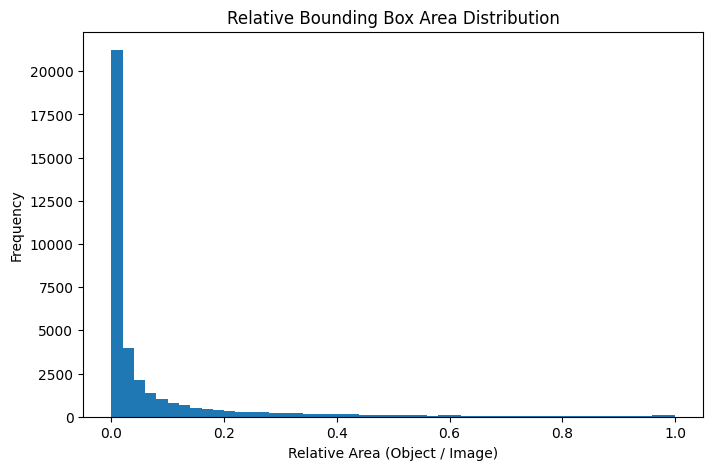

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df_annotations["bbox_relative_area"], bins=50)

plt.title("Relative Bounding Box Area Distribution")
plt.xlabel("Relative Area (Object / Image)")
plt.ylabel("Frequency")

plt.show()

The distribution shows that **most objects occupy only a small portion of the image**, with relative areas close to zero. As the relative area increases, the number of objects decreases rapidly. This indicates that the dataset mainly contains **small objects**, while large objects that cover a significant part of the image are relatively rare.


##### Objects per Category Table

In [20]:
category_summary = (
    df_annotations["category_name"]
    .value_counts()
    .reset_index()
)

category_summary.columns = ["category", "num_objects"]

category_summary.head(10)

,category,num_objects
0,person,11004
1,car,1932
2,chair,1791
3,book,1161
4,bottle,1025
5,cup,899
6,dining table,697
7,traffic light,637
8,bowl,626
9,handbag,540


The table shows the **most frequent object categories** in the dataset. The category **person** appears far more often than any other class, with over **11,000 instances**, while the remaining categories such as **car**, **chair**, and **book** appear significantly less frequently. This further demonstrates that the dataset has a **strong class imbalance**, where a few categories dominate the annotations.
This table summarizes the most common object categories in the dataset.

##### Top Categories Pie Chart

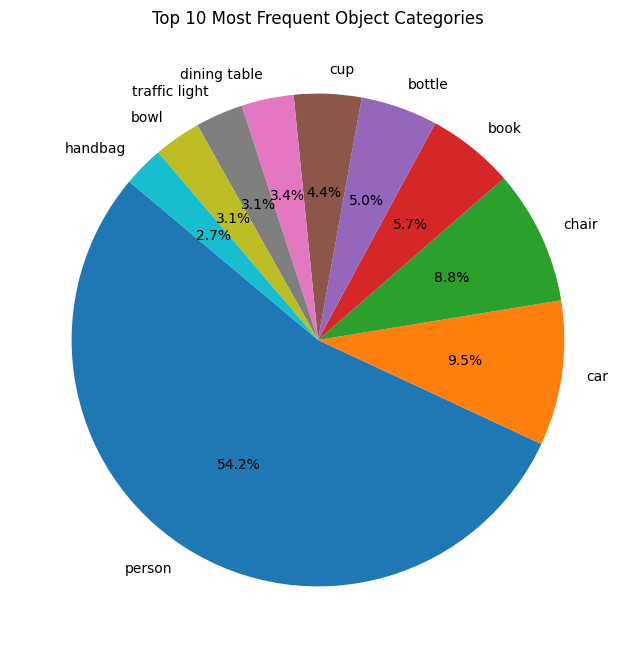

In [21]:
top_n = 10

top_categories = df_annotations["category_name"].value_counts().head(top_n)

plt.figure(figsize=(8,8))

plt.pie(
    top_categories.values,
    labels=top_categories.index,
    autopct="%1.1f%%",
    startangle=140
)

plt.title(f"Top {top_n} Most Frequent Object Categories")

plt.show()

The pie chart shows that the category **person** dominates the dataset, accounting for more than **half of the objects (~54%)** among the top categories. Other classes such as **car**, **chair**, and **book** appear much less frequently. This indicates a **strong class imbalance**, where a few categories contribute a large portion of the annotations while many others appear relatively rarely.


# 4.

##### Initialization

In [22]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("Model loaded")

Model loaded


In [23]:
import os
import time
import json
import pickle
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from io import BytesIO
from PIL import Image
from ultralytics import YOLO

## 4.1 - Detection on a selected image

We select an image containing multiple objects from different categories and run YOLOv8n on it.

The model predictions are compared with the ground-truth annotations of the COCO dataset.

Two thresholds are used:

- **Confidence threshold = 0.25**  
  removes weak detections

- **IoU threshold = 0.50**  
  determines whether a prediction overlaps sufficiently with ground truth


***AI used [3]***

##### **Choose image with multiple objects**

In [24]:
# Create a DataFrame with image-level statistics
image_stats = []

for img_id in img_ids:

    ann_ids = coco.getAnnIds(imgIds=[img_id])
    anns = coco.loadAnns(ann_ids)

    categories = [ann["category_id"] for ann in anns]

    image_stats.append({
        "image_id": img_id,
        "num_objects": len(anns),
        "num_categories": len(set(categories))
    })

df_image_stats = pd.DataFrame(image_stats)

df_image_stats.head()

,image_id,num_objects,num_categories
0,397133,19,11
1,37777,14,8
2,252219,7,5
3,87038,17,3
4,174482,12,4


In [25]:
# Select candidate images with multiple objects and categories
candidate_images = df_image_stats[
    (df_image_stats["num_objects"] >= 5) &
    (df_image_stats["num_categories"] >= 3)
].sort_values(
    by=["num_categories", "num_objects"],
    ascending=False
)

candidate_images.head(10)

,image_id,num_objects,num_categories
3447,441247,24,14
938,435081,63,13
330,226147,21,13
3711,540502,20,13
2926,338905,38,12
3068,575970,29,12
2055,190236,28,12
1269,419974,25,12
848,246968,22,12
4435,74209,21,12


In [26]:
chosen_img_id = int(candidate_images.iloc[0]["image_id"])

print("Chosen image:", chosen_img_id)

Chosen image: 441247


##### **Load image and Ground Truth**

In [27]:
img_info = coco.loadImgs(chosen_img_id)[0]

response = requests.get(img_info["coco_url"])
image = Image.open(BytesIO(response.content)).convert("RGB")

ann_ids = coco.getAnnIds(imgIds=[chosen_img_id])
anns = coco.loadAnns(ann_ids)

print("Image ID:", img_info["id"])
print("Number of GT objects:", len(anns))

Image ID: 441247
Number of GT objects: 24


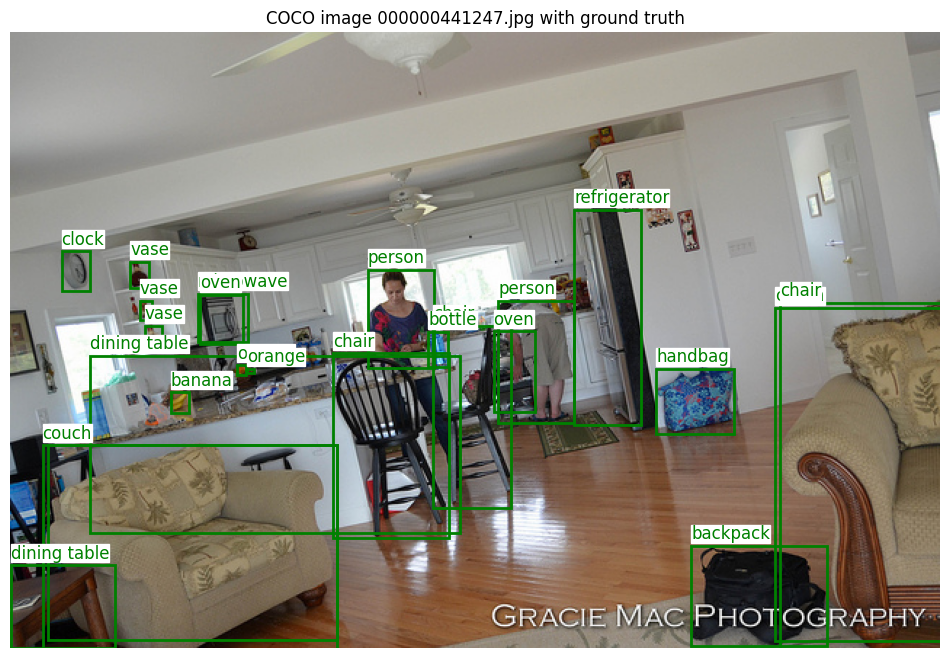

In [28]:
# Reuse helper instead of duplicating GT visualization logic
show_coco_image_with_gt(coco, chosen_img_id, cat_id_to_name, box_color='green')

##### **Run YOLO**

In [29]:
CONF_THRESHOLD = 0.25

result = model.predict(source=image, conf=CONF_THRESHOLD, device=device, verbose=False)[0]

df_preds = pd.DataFrame([
    {
        "x1": box[0],
        "y1": box[1],
        "x2": box[2],
        "y2": box[3],
        "category": model.names[cls],
        "confidence": conf
    }
    for box, cls, conf in zip(
        result.boxes.xyxy.cpu().numpy(),
        result.boxes.cls.cpu().numpy().astype(int),
        result.boxes.conf.cpu().numpy()
    )
])

df_gt = pd.DataFrame([
    {
        "x1": x,
        "y1": y,
        "x2": x + w,
        "y2": y + h,
        "category": cat_id_to_name[ann["category_id"]]
    }
    for ann in anns
    for x, y, w, h in [ann["bbox"]]
])

df_preds, df_gt

(            x1          y1          x2          y2  category  confidence
 0   222.667297  224.195740  301.249695  344.804199     chair    0.882257
 1   528.577820  183.822525  639.788025  415.145386     couch    0.787920
 2    34.651432  150.878540   53.885448  177.109558     clock    0.715079
 3    24.345520  283.061768  221.952728  421.694641     couch    0.685306
 4   349.983276  184.214478  386.995361  268.128845    person    0.671805
 5     0.000000  305.658142   68.842331  421.152283     chair    0.534919
 6   158.371216  285.182068  197.153076  302.456177     chair    0.459533
 7   246.436523  162.830536  309.037292  316.194763    person    0.383003
 8    25.142990  282.333984  221.503174  421.323608     chair    0.348810
 9   246.316559  163.300888  291.961884  231.432266    person    0.320887
 10  276.915405  231.257507  347.157959  325.501648     chair    0.317052
 11  335.815979  181.157440  387.635315  268.288055    person    0.289720
 12  473.961121  354.412415  561.80645

##### **IoU function**

In [30]:
def compute_iou(boxA,boxB):

    xA=max(boxA[0],boxB[0])
    yA=max(boxA[1],boxB[1])
    xB=min(boxA[2],boxB[2])
    yB=min(boxA[3],boxB[3])

    inter=max(0,xB-xA)*max(0,yB-yA)

    areaA=(boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    areaB=(boxB[2]-boxB[0])*(boxB[3]-boxB[1])

    union=areaA+areaB-inter

    if union==0:
        return 0

    return inter/union

##### **Match predictions with GT**

In [31]:

IOU_THRESHOLD = 0.5
matched_gt = set()
matches = []

for pred_i, pred in df_preds.iterrows():

    best_iou = 0
    best_gt = None
    pred_box = [pred.x1, pred.y1, pred.x2, pred.y2]

    for gt_i, gt in df_gt.iterrows():

        if gt_i in matched_gt or gt.category != pred.category:
            continue

        gt_box = [gt.x1, gt.y1, gt.x2, gt.y2]
        iou = compute_iou(pred_box, gt_box)

        if iou > best_iou:
            best_iou = iou
            best_gt = gt_i

    if best_gt is not None and best_iou >= IOU_THRESHOLD:
        matched_gt.add(best_gt)
        status = "TP"
    else:
        status = "FP"

    matches.append({"prediction": pred_i, "status": status, "iou": best_iou})

df_matches = pd.DataFrame(matches)
df_matches

,prediction,status,iou
0,0,TP,0.936944
1,1,TP,0.938733
2,2,TP,0.928781
3,3,TP,0.952867
4,4,TP,0.706093
5,5,FP,0.163070
6,6,FP,0.025042
7,7,FP,0.310273
8,8,TP,0.952685
9,9,TP,0.954902


##### **Visualization**

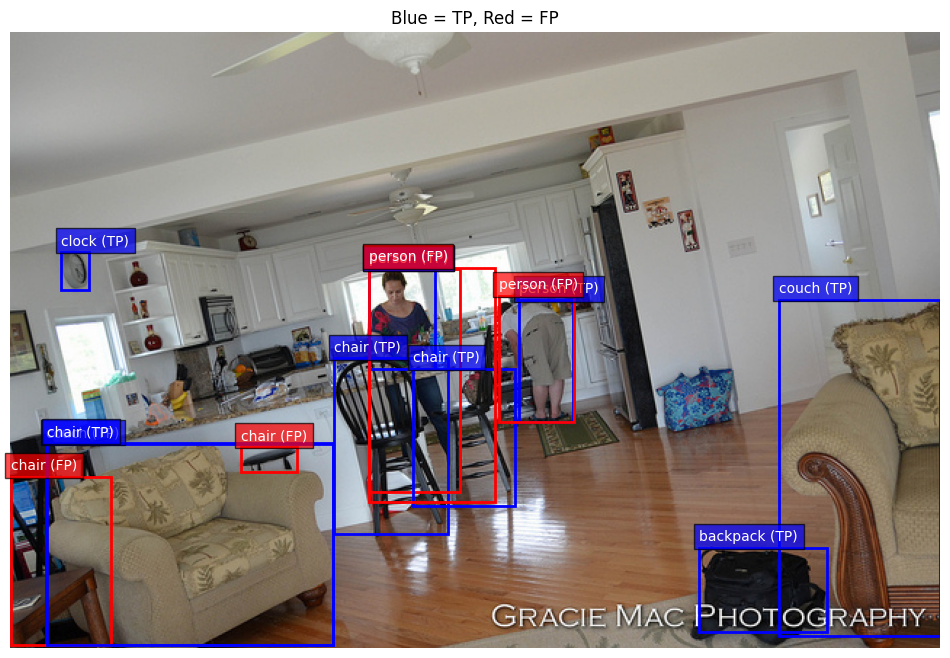

In [32]:
# Visualize predictions with TP/FP coloring

plt.figure(figsize=(12,10))
plt.imshow(image)
plt.axis("off")

ax = plt.gca()

def draw_box(row, color, label):
    ax.add_patch(
        plt.Rectangle(
            (row.x1, row.y1),
            row.x2 - row.x1,
            row.y2 - row.y1,
            fill=False,
            edgecolor=color,
            linewidth=2
        )
    )

    ax.text(
        row.x1,
        row.y1 - 5,
        label,
        color="white",
        bbox=dict(facecolor=color, alpha=0.7)
    )


for i, row in df_preds.iterrows():
    status = df_matches.iloc[i].status
    color = "blue" if status == "TP" else "red"
    draw_box(row, color, f"{row.category} ({status})")

plt.title("Blue = TP, Red = FP")
plt.show()

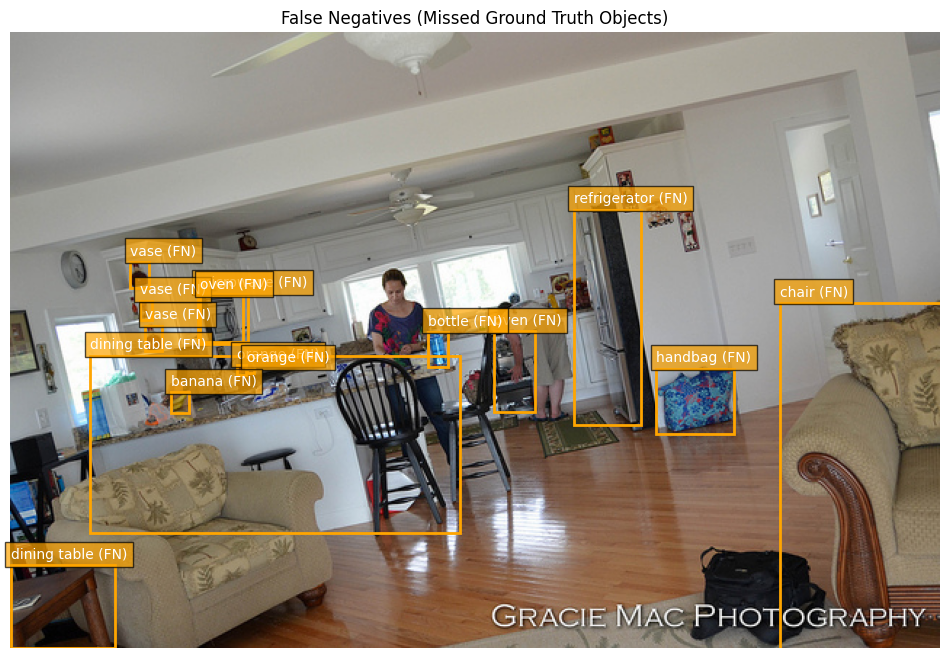

In [33]:
# Visualize False Negatives (missed GT objects)

plt.figure(figsize=(12,10))
plt.imshow(image)
plt.axis("off")

ax = plt.gca()

for gt_i, row in df_gt.iterrows():

    if gt_i not in matched_gt:   # this is a False Negative

        ax.add_patch(
            plt.Rectangle(
                (row.x1, row.y1),
                row.x2 - row.x1,
                row.y2 - row.y1,
                fill=False,
                edgecolor="orange",
                linewidth=2
            )
        )

        ax.text(
            row.x1,
            row.y1 - 5,
            f"{row.category} (FN)",
            color="white",
            bbox=dict(facecolor="orange", alpha=0.7)
        )

plt.title("False Negatives (Missed Ground Truth Objects)")
plt.show()

In [34]:
# Report results in a table

results_rows = []

for i, pred in df_preds.iterrows():

    status = df_matches.iloc[i]["status"]
    iou = df_matches.iloc[i]["iou"]

    results_rows.append({
        "prediction_id": i,
        "category": pred.category,
        "confidence": round(pred.confidence,3),
        "IoU": round(iou,3),
        "result": status
    })

df_results = pd.DataFrame(results_rows)

df_results

,prediction_id,category,confidence,IoU,result
0,0,chair,0.882,0.937,TP
1,1,couch,0.788,0.939,TP
2,2,clock,0.715,0.929,TP
3,3,couch,0.685,0.953,TP
4,4,person,0.672,0.706,TP
5,5,chair,0.535,0.163,FP
6,6,chair,0.460,0.025,FP
7,7,person,0.383,0.310,FP
8,8,chair,0.349,0.953,TP
9,9,person,0.321,0.955,TP


In [35]:
# Compute summary statistics

TP = (df_results.result=="TP").sum()
FP = (df_results.result=="FP").sum()
FN = len(df_gt) - TP

summary = {
    "True Positives": TP,
    "False Positives": FP,
    "False Negatives": FN,
    "Total GT objects": len(df_gt),
    "Total predictions": len(df_preds)
}

# Print summary

print("Detection summary")
print("-----------------")
print("TP:", TP)
print("FP:", FP)
print("FN:", FN)

Detection summary
-----------------
TP: 9
FP: 5
FN: 15


### Detection Results Summary

The model produced **14 predictions** for the selected image, including **9 True Positives (TP)** and **5 False Positives (FP)**. Most of the true positives have **high IoU values (around 0.7-0.95)**, indicating strong overlap with the ground truth objects. The false positives generally have **low IoU values**, meaning the predicted boxes do not correspond well to any ground truth object. In addition, there are **15 False Negatives (FN)**, which are ground truth objects that the model failed to detect. Overall, while the model correctly detects several objects, it still misses a significant number of them.


## 4.2 - Evaluation on the full validation dataset

In this section, we repeat the detection analysis for all images in the COCO validation dataset.

For each image, YOLOv8n predictions are compared with the ground-truth annotations using an IoU threshold of 0.5.

For every object category, we compute:

- **Precision**
- **Recall**
- **Average Precision (AP)** - area under the precision-recall curve

***AI used [4]***

##### Evaluation thresholds

In [36]:
IOU_THRESHOLD = 0.50
PR_CONF_THRESHOLD = 0.25
AP_MIN_CONF = 0.001

print("IoU threshold:", IOU_THRESHOLD)
print("Precision/Recall confidence threshold:", PR_CONF_THRESHOLD)
print("Minimum confidence collected for AP:", AP_MIN_CONF)

IoU threshold: 0.5
Precision/Recall confidence threshold: 0.25
Minimum confidence collected for AP: 0.001


##### Helper functions

In [37]:
# Redundant imports removed: numpy, tqdm, requests, BytesIO, and PIL are already imported above.


In [38]:
# compute_iou is already defined in section 4.1 and reused below.


In [103]:
# Helper to compute Average Precision from recall and precision
def compute_ap(recalls, precisions):
    recalls = np.array(recalls)
    precisions = np.array(precisions)

    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))

    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])

    return ap


def select_metrics_at_iou(df_ap_all, iou_threshold=IOU_THRESHOLD):
    return (
        df_ap_all[df_ap_all["iou_threshold"] == iou_threshold]
        .sort_values("AP", ascending=False)
        .reset_index(drop=True)
    )


def compute_map_scores(df_ap_all, map_iou=0.50):
    map50 = df_ap_all[df_ap_all["iou_threshold"] == map_iou]["AP"].mean()
    map50_95 = df_ap_all["AP"].mean()
    return map50, map50_95


def build_comparison_summary(original_scores, variant_label, variant_scores, extra_scores=None):
    summary = {
        "metric": ["mAP@50", "mAP@50-95"],
        "original": [original_scores[0], original_scores[1]],
        variant_label: [variant_scores[0], variant_scores[1]],
    }

    if extra_scores:
        for label, scores in extra_scores.items():
            summary[label] = [scores[0], scores[1]]

    df = pd.DataFrame(summary)
    df["absolute_drop"] = df["original"] - df[variant_label]
    df["relative_drop_percent"] = 100 * df["absolute_drop"] / df["original"]
    return df


def build_ap_drop_table(df_original_metrics, df_variant_metrics, variant_label):
    df_ap_compare = df_original_metrics[["category", "AP"]].merge(
        df_variant_metrics[["category", "AP"]],
        on="category",
        suffixes=("_original", f"_{variant_label}"),
    )

    df_ap_compare["AP_drop"] = (
        df_ap_compare["AP_original"] - df_ap_compare[f"AP_{variant_label}"]
    )

    return df_ap_compare.sort_values("AP_drop", ascending=False).reset_index(drop=True)


def plot_pr_curves(pr_curves, category_names, df_category_metrics, title, n_cats=5):
    random_cats = random.sample(category_names, min(n_cats, len(category_names)))
    plt.figure(figsize=(8, 6))

    for cat in random_cats:
        recall, precision = pr_curves[cat]
        ap = df_category_metrics[df_category_metrics["category"] == cat]["AP"].values[0]
        plt.step(recall, precision, where="post", label=f"{cat} (AP={ap:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_ap_drop_bars(df_ap_compare, title, top_n=15):
    plt.figure(figsize=(12, 6))
    plt.bar(df_ap_compare["category"].head(top_n), df_ap_compare["AP_drop"].head(top_n))
    plt.xticks(rotation=75)
    plt.ylabel("AP drop")
    plt.xlabel("Category")
    plt.title(f"Top {top_n} Categories Most Affected by {title}")
    plt.tight_layout()
    plt.show()


In [40]:
def evaluate_ap_per_category(df_all_predictions, category_names,
                             gt_boxes_by_image_and_cat, gt_count_per_cat,
                             iou_threshold):
    category_results = []
    pr_curves = {}

    for cat_name in category_names:
        preds_cat = df_all_predictions[df_all_predictions["category"] == cat_name]
        preds_cat = preds_cat.sort_values("confidence", ascending=False)

        total_gt = gt_count_per_cat[cat_name]
        matched_gt_by_image = {}

        tp_flags = []
        fp_flags = []

        for _, pred_row in preds_cat.iterrows():
            img_id = pred_row["image_id"]
            pred_box = pred_row["box"]

            gt_boxes = gt_boxes_by_image_and_cat.get(img_id, {}).get(cat_name, [])

            if img_id not in matched_gt_by_image:
                matched_gt_by_image[img_id] = set()

            best_iou = 0
            best_gt_idx = None

            for gt_idx, gt_box in enumerate(gt_boxes):
                if gt_idx in matched_gt_by_image[img_id]:
                    continue

                iou = compute_iou(pred_box, gt_box)

                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx

            if best_gt_idx is not None and best_iou >= iou_threshold:
                matched_gt_by_image[img_id].add(best_gt_idx)
                tp_flags.append(1)
                fp_flags.append(0)
            else:
                tp_flags.append(0)
                fp_flags.append(1)

        tp_flags = np.array(tp_flags)
        fp_flags = np.array(fp_flags)

        cum_tp = np.cumsum(tp_flags)
        cum_fp = np.cumsum(fp_flags)

        if total_gt > 0:
            recalls = cum_tp / total_gt
        else:
            recalls = np.zeros_like(cum_tp, dtype=float)

        precisions = cum_tp / np.maximum(cum_tp + cum_fp, 1e-9)
        ap = compute_ap(recalls, precisions) if len(precisions) > 0 else 0.0

        pr_curves[cat_name] = (recalls, precisions)

        preds_thr = preds_cat["confidence"].values >= PR_CONF_THRESHOLD

        tp_thr = int(tp_flags[preds_thr].sum())
        fp_thr = int(fp_flags[preds_thr].sum())
        fn_thr = int(total_gt - tp_thr)

        precision_thr = tp_thr / (tp_thr + fp_thr) if (tp_thr + fp_thr) > 0 else 0.0
        recall_thr = tp_thr / total_gt if total_gt > 0 else 0.0

        category_results.append({
            "category": cat_name,
            "iou_threshold": iou_threshold,
            "num_gt": int(total_gt),
            "num_predictions_above_threshold": int(preds_thr.sum()),
            "TP": tp_thr,
            "FP": fp_thr,
            "FN": fn_thr,
            "precision": precision_thr,
            "recall": recall_thr,
            "AP": ap
        })

    return pd.DataFrame(category_results), pr_curves

##### Prepare GT structures

In [41]:
category_names = sorted(df_annotations["category_name"].unique())

gt_boxes_by_image_and_cat = {}
gt_count_per_cat = {cat: 0 for cat in category_names}

for img_id in img_ids:

    gt_boxes_by_image_and_cat[img_id] = {}

    for ann in coco.loadAnns(coco.getAnnIds(imgIds=[img_id])):

        cat = cat_id_to_name[ann["category_id"]]
        x, y, w, h = ann["bbox"]
        box = [x, y, x+w, y+h]

        gt_boxes_by_image_and_cat[img_id].setdefault(cat, []).append(box)
        gt_count_per_cat[cat] += 1

print("Number of categories:", len(category_names))
print("Example categories:", category_names[:10])

Number of categories: 80
Example categories: ['airplane', 'apple', 'backpack', 'banana', 'baseball bat', 'baseball glove', 'bear', 'bed', 'bench', 'bicycle']


##### Run YOLOv8n on all images

In [42]:
images_dir = os.path.join(os.getcwd(), "val2017")

if not os.path.exists(images_dir):
    raise FileNotFoundError("val2017 folder not found")

print("Images folder:", images_dir)

Images folder: c:\Users\Yuval\Desktop\Rupin\Year 4\עיבוד תמונה וראייה ממוחשבת\final\val2017


In [43]:
all_predictions = []

for img_id in img_ids:
    img_info = coco.loadImgs(img_id)[0]
    image_path = os.path.join(images_dir, img_info["file_name"])

    if not os.path.exists(image_path):
        continue

    image = Image.open(image_path).convert("RGB")
    result = model.predict(source=image, conf=AP_MIN_CONF, device=device, verbose=False)[0]

    if result.boxes is None or len(result.boxes) == 0:
        continue

    for box, cls_id, conf in zip(
        result.boxes.xyxy.cpu().numpy(),
        result.boxes.cls.cpu().numpy().astype(int),
        result.boxes.conf.cpu().numpy()
    ):
        category = model.names[cls_id]

        if category in category_names:
            all_predictions.append({
                "image_id": img_id,
                "category": category,
                "confidence": float(conf),
                "box": box.tolist()
            })

print("Total collected predictions:", len(all_predictions))

Total collected predictions: 693213


In [44]:
df_all_predictions = pd.DataFrame(all_predictions)
df_all_predictions.head()

,image_id,category,confidence,box
0,397133,person,0.893030,"[385.28936767578125, 67.62957763671875, 498.84..."
1,397133,bowl,0.747342,"[155.19747924804688, 169.18133544921875, 182.2..."
2,397133,bowl,0.743088,"[58.235408782958984, 288.7991027832031, 135.51..."
3,397133,bowl,0.713241,"[30.747528076171875, 343.49481201171875, 99.87..."
4,397133,oven,0.571746,"[0.0, 183.37973022460938, 194.74969482421875, ..."


##### Evaluate each category

In [45]:
df_category_metrics, pr_curves = evaluate_ap_per_category(
    df_all_predictions=df_all_predictions,
    category_names=category_names,
    gt_boxes_by_image_and_cat=gt_boxes_by_image_and_cat,
    gt_count_per_cat=gt_count_per_cat,
    iou_threshold=IOU_THRESHOLD
)


In [46]:
# Sort categories by AP
df_category_metrics = pd.DataFrame(df_category_metrics)
df_category_metrics = df_category_metrics.sort_values("AP", ascending=False).reset_index(drop=True)
df_category_metrics

,category,iou_threshold,num_gt,num_predictions_above_threshold,TP,FP,FN,precision,recall,AP
0,giraffe,0.5,232,224,193,31,39,0.861607,0.831897,0.887152
1,zebra,0.5,268,259,213,46,55,0.822394,0.794776,0.881130
2,airplane,0.5,143,140,109,31,34,0.778571,0.762238,0.839361
3,cat,0.5,202,219,171,48,31,0.780822,0.846535,0.834309
4,train,0.5,190,186,147,39,43,0.790323,0.773684,0.829882
...,...,...,...,...,...,...,...,...,...,...
75,backpack,0.5,371,115,59,56,312,0.513043,0.159030,0.178198
76,knife,0.5,326,104,49,55,277,0.471154,0.150307,0.165089
77,spoon,0.5,253,70,31,39,222,0.442857,0.122530,0.163850
78,handbag,0.5,540,135,65,70,475,0.481481,0.120370,0.156365


##### Summary and plots

In [47]:
mean_precision = df_category_metrics["precision"].mean()
mean_recall = df_category_metrics["recall"].mean()
mean_ap = df_category_metrics["AP"].mean()

print("Overall summary")
print("---------------")
print("Mean Precision:", round(mean_precision, 4))
print("Mean Recall:", round(mean_recall, 4))
print("Mean AP:", round(mean_ap, 4))

Overall summary
---------------
Mean Precision: 0.6382
Mean Recall: 0.4641
Mean AP: 0.5087


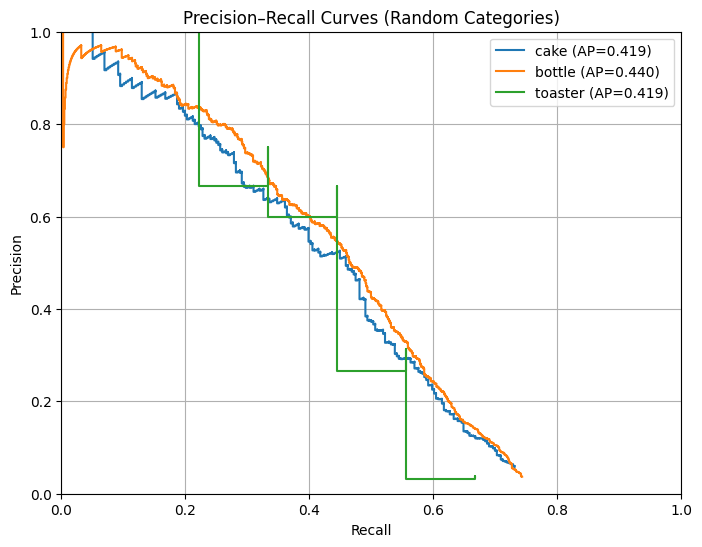

In [48]:
random_cats = random.sample(category_names, 3)

plt.figure(figsize=(8,6))

for cat in random_cats:
    recall, precision = pr_curves[cat]
    ap = df_category_metrics[df_category_metrics["category"] == cat]["AP"].values[0]

    plt.step(recall, precision, where="post", label=f"{cat} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (Random Categories)")
plt.xlim(0,1)
plt.ylim(0,1)

plt.legend()
plt.grid(True)
plt.show()

In [49]:
print("Top 10 categories by AP")
display(df_category_metrics.head(10))

print("Bottom 10 categories by AP")
display(df_category_metrics.tail(10))

Top 10 categories by AP


,category,iou_threshold,num_gt,num_predictions_above_threshold,TP,FP,FN,precision,recall,AP
0,giraffe,0.5,232,224,193,31,39,0.861607,0.831897,0.887152
1,zebra,0.5,268,259,213,46,55,0.822394,0.794776,0.881130
2,airplane,0.5,143,140,109,31,34,0.778571,0.762238,0.839361
3,cat,0.5,202,219,171,48,31,0.780822,0.846535,0.834309
4,train,0.5,190,186,147,39,43,0.790323,0.773684,0.829882
5,bear,0.5,71,60,53,7,18,0.883333,0.746479,0.813245
6,elephant,0.5,255,296,208,88,47,0.702703,0.815686,0.806120
7,toilet,0.5,179,183,132,51,47,0.721311,0.737430,0.769625
8,fire hydrant,0.5,101,83,71,12,30,0.855422,0.702970,0.769100
9,frisbee,0.5,115,112,83,29,32,0.741071,0.721739,0.758206


Bottom 10 categories by AP


,category,iou_threshold,num_gt,num_predictions_above_threshold,TP,FP,FN,precision,recall,AP
70,bench,0.5,413,192,111,81,302,0.578125,0.268765,0.293304
71,remote,0.5,283,134,62,72,221,0.462687,0.219081,0.275292
72,toothbrush,0.5,57,21,11,10,46,0.523810,0.192982,0.241379
73,apple,0.5,239,121,55,66,184,0.454545,0.230126,0.226986
74,book,0.5,1161,234,108,126,1053,0.461538,0.093023,0.183723
75,backpack,0.5,371,115,59,56,312,0.513043,0.159030,0.178198
76,knife,0.5,326,104,49,55,277,0.471154,0.150307,0.165089
77,spoon,0.5,253,70,31,39,222,0.442857,0.122530,0.163850
78,handbag,0.5,540,135,65,70,475,0.481481,0.120370,0.156365
79,hair drier,0.5,11,0,0,0,11,0.000000,0.000000,0.006993


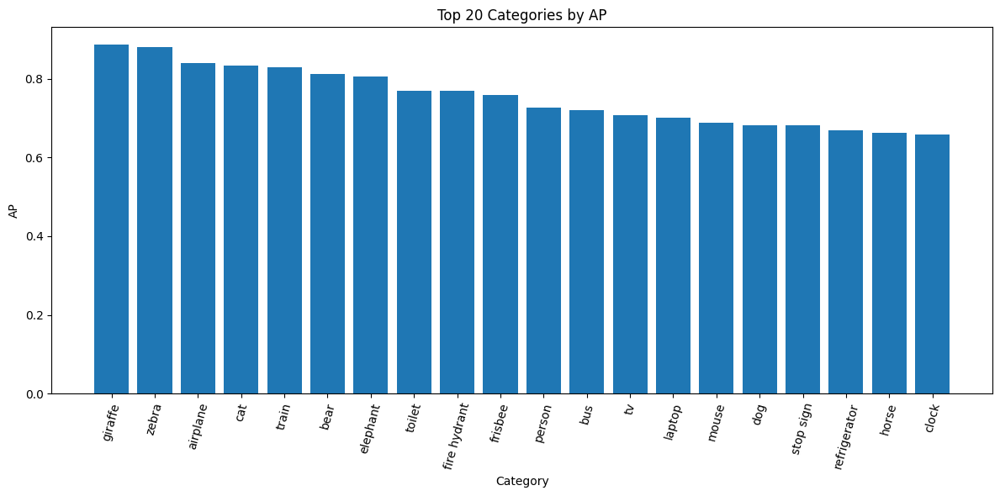

In [50]:
top_n = 20

plt.figure(figsize=(12, 6))
plt.bar(df_category_metrics["category"].head(top_n), df_category_metrics["AP"].head(top_n))
plt.xticks(rotation=75)
plt.ylabel("AP")
plt.xlabel("Category")
plt.title(f"Top {top_n} Categories by AP")
plt.tight_layout()
plt.show()

The model shows **moderate overall performance**, with a **mean AP of 0.50**, **mean precision of 0.64**, and **mean recall of 0.46**. This indicates that predictions are often correct, but the model still **misses many objects**, leading to lower recall.

Performance also varies across categories. Some classes such as **giraffe and zebra** achieve high AP values (around **0.88**), while others like **bench or book** perform much worse. This suggests the model detects **clear and distinctive objects more reliably**, while more difficult categories are harder to detect.


## 4.3 - Computing mAP@50 and mAP@50-95

In this section, we evaluate the object detection performance using two common metrics: **mAP@50** and **mAP@50-95**.

For each category, predicted bounding boxes are matched with ground-truth objects of the same class using the **Intersection over Union (IoU)** metric. A prediction is considered a **True Positive** if its IoU with a ground-truth box is greater than or equal to the chosen threshold. Using these matches, a **precision–recall curve** is constructed and the **Average Precision (AP)** is computed.

Two metrics are then calculated:

* **mAP@50** - the mean AP across all categories when the IoU threshold is **0.50**.
* **mAP@50-95** - the mean AP averaged across all categories and across IoU thresholds from **0.50 to 0.95** with a step of **0.05**.

In [51]:
iou_thresholds = np.arange(0.50, 1.00, 0.05)
print("IoU thresholds:", iou_thresholds)

IoU thresholds: [        0.5        0.55         0.6        0.65         0.7        0.75         0.8        0.85         0.9        0.95]


##### Compute AP for all IoU thresholds

In [52]:
all_tr_ap_tables = []

for iou_thr in iou_thresholds:
    df_metrics, _ = evaluate_ap_per_category(
        df_all_predictions=df_all_predictions,
        category_names=category_names,
        gt_boxes_by_image_and_cat=gt_boxes_by_image_and_cat,
        gt_count_per_cat=gt_count_per_cat,
        iou_threshold=iou_thr
    )

    all_tr_ap_tables.append(df_metrics)

df_ap_all = pd.concat(all_tr_ap_tables, ignore_index=True)
df_ap_all.head()

,category,iou_threshold,num_gt,num_predictions_above_threshold,TP,FP,FN,precision,recall,AP
0,airplane,0.5,143,140,109,31,34,0.778571,0.762238,0.839361
1,apple,0.5,239,121,55,66,184,0.454545,0.230126,0.226986
2,backpack,0.5,371,115,59,56,312,0.513043,0.159030,0.178198
3,banana,0.5,379,196,109,87,270,0.556122,0.287599,0.361320
4,baseball bat,0.5,146,89,52,37,94,0.584270,0.356164,0.388810


##### mAP@50 and mAP@50-95

In [53]:
map_50_og = df_ap_all[df_ap_all["iou_threshold"] == 0.50]["AP"].mean()
map_50_95_og = df_ap_all["AP"].mean()

print("mAP@50 =", round(map_50_og, 4))
print("mAP@50-95 =", round(map_50_95_og, 4))

mAP@50 = 0.5087
mAP@50-95 = 0.3599


##### Mean AP per category across IoU thresholds

In [54]:
df_ap_pivot = df_ap_all.pivot(index="category", columns="iou_threshold", values="AP")
df_category_map = df_ap_pivot.copy()
df_category_map["AP_mean_50_95"] = df_category_map.mean(axis=1)
df_category_map = df_category_map.sort_values("AP_mean_50_95", ascending=False)

df_category_map

iou_threshold,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,AP_mean_50_95
category,,,,,,,,,,,
giraffe,0.887152,0.864224,0.850128,0.833188,0.808072,0.732511,0.678160,0.580320,0.444229,0.135906,0.681389
zebra,0.881130,0.857127,0.839893,0.817486,0.779909,0.733918,0.656207,0.547942,0.412419,0.085154,0.661119
bear,0.813245,0.802817,0.799124,0.798791,0.762187,0.733757,0.656857,0.596449,0.452547,0.120516,0.653629
airplane,0.839361,0.832346,0.826102,0.789559,0.745046,0.710866,0.631751,0.547218,0.441824,0.156416,0.652049
cat,0.834309,0.827930,0.818527,0.799966,0.743974,0.693032,0.596240,0.491519,0.374914,0.127104,0.630752
...,...,...,...,...,...,...,...,...,...,...,...
knife,0.165089,0.157821,0.140667,0.128650,0.114080,0.104209,0.080506,0.053045,0.025736,0.007939,0.097774
backpack,0.178198,0.166389,0.151871,0.136362,0.115234,0.081448,0.050782,0.023441,0.006192,0.000003,0.090992
book,0.183723,0.165587,0.143938,0.123643,0.100898,0.069180,0.042560,0.025365,0.008543,0.001513,0.086495


### Conclusion

The detector achieves **mAP@50 = 0.5087** and **mAP@50–95 = 0.3599**, indicating moderate overall detection performance. The noticeable drop from mAP@50 to mAP@50–95 suggests that while the model often detects objects correctly, the **bounding box localization becomes less accurate under stricter IoU thresholds**.

Performance varies significantly across categories. Large and distinctive objects such as **giraffe, zebra, airplane, bear, and train** achieve high AP values, while smaller or more visually complex objects such as **spoon, backpack, book, handbag, and hair drier** show much lower AP. This indicates that the model performs better on **large, well-defined objects** and struggles with **small or cluttered objects**.


# 5.

## 5.1 - Effect of noise

In this experiment, Gaussian noise is added to the input images, and the full evaluation process from 4 is repeated.

We use additive Gaussian noise of the form:

\[
I_{noisy}(x,y,c) = I(x,y,c) + n(x,y,c)
\]

where \(n(x,y,c)\) is sampled from a zero-mean Gaussian distribution.
we used STD=25 as its visibly noticable in the image

***AI used [5]***

##### noise function + example

In [55]:
def add_gaussian_noise(pil_image, mean=0, std=25):
    img_np = np.array(pil_image).astype(np.float32)

    noise = np.random.normal(loc=mean, scale=std, size=img_np.shape)
    noisy_img = img_np + noise

    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

    return Image.fromarray(noisy_img)

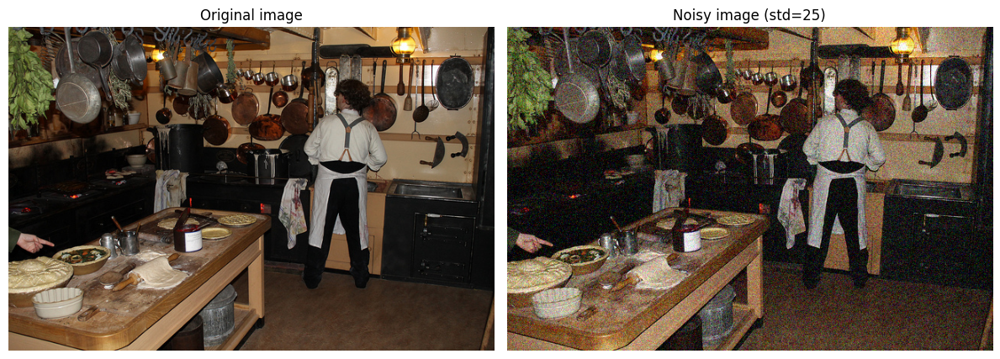

In [56]:
sample_img_info = coco.loadImgs(img_ids[0])[0]
sample_image_path = os.path.join(images_dir, sample_img_info["file_name"])

sample_image = Image.open(sample_image_path).convert("RGB")
sample_noisy_image = add_gaussian_noise(sample_image)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(sample_image)
plt.title("Original image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sample_noisy_image)
plt.title(f"Noisy image (std=25)")
plt.axis("off")

plt.tight_layout()
plt.show()

We can clearly see the added noise in the image above.

##### Run YOLO on noisy images

In [57]:
all_predictions_noisy = []

for img_id in img_ids:
    img_info = coco.loadImgs(img_id)[0]
    image_path = os.path.join(images_dir, img_info["file_name"])

    image = Image.open(image_path).convert("RGB")
    noisy_image = add_gaussian_noise(image)

    result = model.predict(source=noisy_image, conf=AP_MIN_CONF, device=device, verbose=False)[0]

    if result.boxes is None:
        continue

    boxes = result.boxes.xyxy.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    for box, cls, conf in zip(boxes, classes, confs):
        category = model.names[cls]

        if category in category_names:
            all_predictions_noisy.append({
                "image_id": img_id,
                "category": category,
                "confidence": float(conf),
                "box": box.tolist()
            })

print("Total predictions (noisy):", len(all_predictions_noisy))

Total predictions (noisy): 690444


##### Metrics results

In [58]:

df_all_predictions_noisy = pd.DataFrame(all_predictions_noisy)
df_ap_all_noisy = []

for thr in iou_thresholds:
    df_ap, pr_curves_noisy_s5 = evaluate_ap_per_category(
        df_all_predictions_noisy,
        category_names,
        gt_boxes_by_image_and_cat,
        gt_count_per_cat,
        thr
    )
    df_ap_all_noisy.append(df_ap)

df_ap_all_noisy = pd.concat(df_ap_all_noisy, ignore_index=True)
df_ap_all_noisy


,category,iou_threshold,num_gt,num_predictions_above_threshold,TP,FP,FN,precision,recall,AP
0,airplane,0.50,143,71,55,16,88,0.774648,0.384615,0.532257
1,apple,0.50,239,17,12,5,227,0.705882,0.050209,0.127049
2,backpack,0.50,371,38,19,19,352,0.500000,0.051213,0.090454
3,banana,0.50,379,39,34,5,345,0.871795,0.089710,0.187035
4,baseball bat,0.50,146,92,47,45,99,0.510870,0.321918,0.302644
...,...,...,...,...,...,...,...,...,...,...
795,tv,0.95,288,135,22,113,266,0.162963,0.076389,0.026010
796,umbrella,0.95,413,313,22,291,391,0.070288,0.053269,0.015556
797,vase,0.95,277,100,8,92,269,0.080000,0.028881,0.012379
798,wine glass,0.95,343,93,8,85,335,0.086022,0.023324,0.011911


### Results

In [59]:
# Per-category metrics at the main IoU threshold
df_category_metrics_noisy = select_metrics_at_iou(df_ap_all_noisy, iou_threshold=IOU_THRESHOLD)
df_category_metrics_noisy

,category,iou_threshold,num_gt,num_predictions_above_threshold,TP,FP,FN,precision,recall,AP
0,zebra,0.5,268,222,187,35,81,0.842342,0.697761,0.817063
1,giraffe,0.5,232,203,162,41,70,0.798030,0.698276,0.739655
2,train,0.5,190,162,117,45,73,0.722222,0.615789,0.679525
3,fire hydrant,0.5,101,66,56,10,45,0.848485,0.554455,0.653042
4,frisbee,0.5,115,59,54,5,61,0.915254,0.469565,0.646443
...,...,...,...,...,...,...,...,...,...,...
75,spoon,0.5,253,30,14,16,239,0.466667,0.055336,0.084467
76,toothbrush,0.5,57,6,3,3,54,0.500000,0.052632,0.082333
77,knife,0.5,326,49,18,31,308,0.367347,0.055215,0.074787
78,handbag,0.5,540,62,22,40,518,0.354839,0.040741,0.062377


In [60]:
# Global noisy detection metrics
map50_noisy, map50_95_noisy = compute_map_scores(df_ap_all_noisy, map_iou=0.50)

print("Noisy mAP@50 =", round(map50_noisy, 4))
print("Noisy mAP@50-95 =", round(map50_95_noisy, 4))

Noisy mAP@50 = 0.3379
Noisy mAP@50-95 = 0.2275


##### Comparison to non-noisy

In [61]:
# Comparison original vs noisy summary
comparison_summary = build_comparison_summary(
    original_scores=(map_50_og, map_50_95_og),
    variant_label="noisy",
    variant_scores=(map50_noisy, map50_95_noisy)
)
comparison_summary

,metric,original,noisy,absolute_drop,relative_drop_percent
0,mAP@50,0.508692,0.337900,0.170791,33.574655
1,mAP@50-95,0.359912,0.227521,0.132391,36.784155


In [62]:
# Category-wise AP comparison
df_ap_compare = build_ap_drop_table(
    df_original_metrics=df_category_metrics,
    df_variant_metrics=df_category_metrics_noisy,
    variant_label="noisy"
)
df_ap_compare.head(10)

,category,AP_original,AP_noisy,AP_drop
0,bus,0.719791,0.378936,0.340855
1,airplane,0.839361,0.532257,0.307104
2,mouse,0.689060,0.395082,0.293978
3,bear,0.813245,0.541946,0.271299
4,parking meter,0.571827,0.302858,0.268970
5,toilet,0.769625,0.510128,0.259498
6,cat,0.834309,0.576467,0.257842
7,elephant,0.806120,0.553641,0.252479
8,suitcase,0.481744,0.231590,0.250154
9,refrigerator,0.668704,0.418798,0.249906


##### Graphs

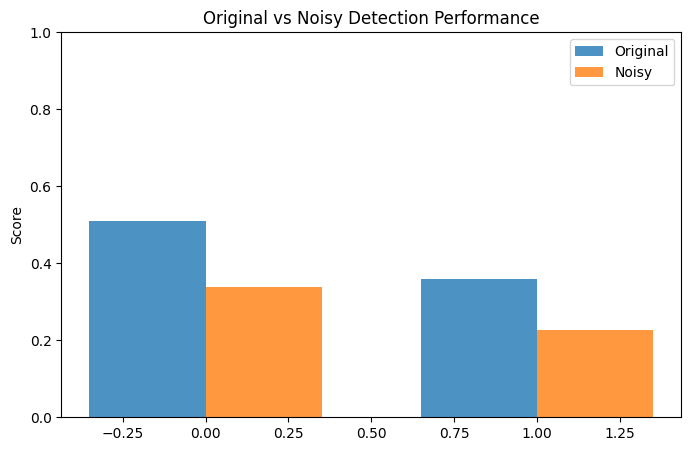

In [63]:
# Visualization of original vs noisy performance

metrics = comparison_summary["metric"]
original = comparison_summary["original"]
noisy = comparison_summary["noisy"]

x = np.arange(len(metrics))
width = 0.35
    

plt.figure(figsize=(8,5))
plt.bar(x - width/2, original, width=width, label="Original", alpha=0.8)
plt.bar(x + width/2, noisy, width=width, label="Noisy", alpha=0.8)

plt.ylabel("Score")
plt.title("Original vs Noisy Detection Performance")
plt.legend()
plt.ylim(0, 1)
plt.show()


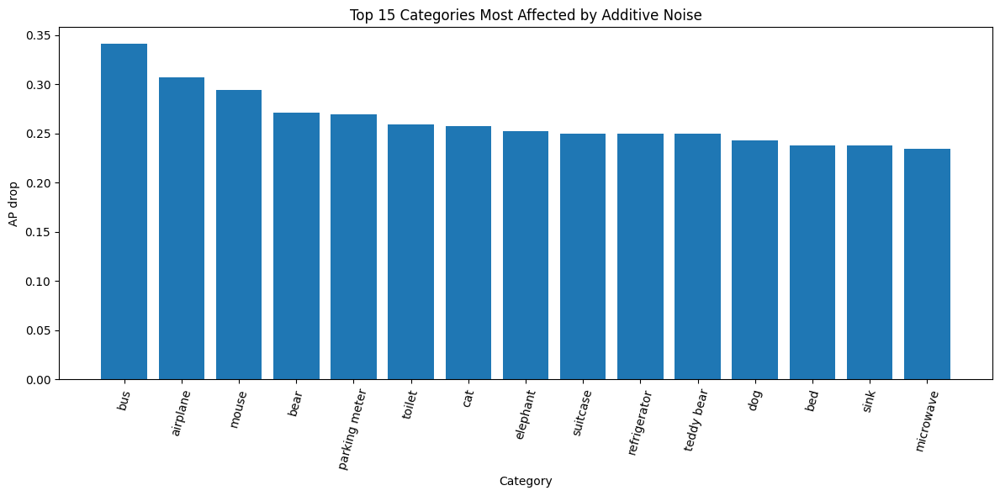

In [64]:
plot_ap_drop_bars(df_ap_compare, title="Additive Noise", top_n=15)


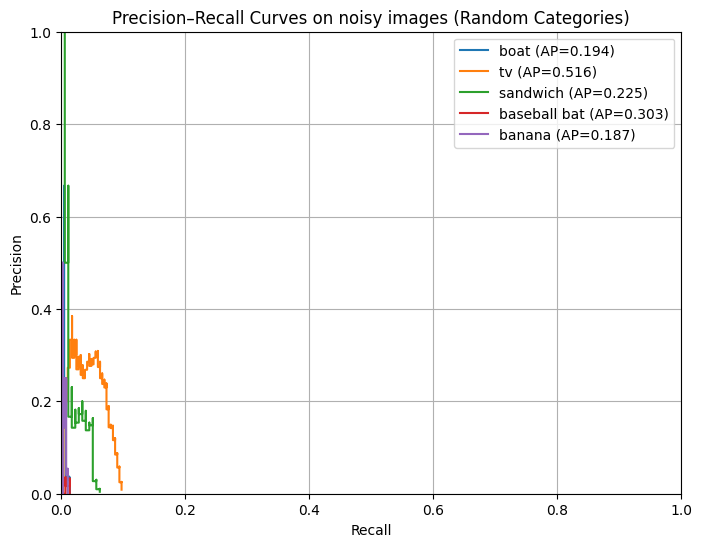

In [65]:
plot_pr_curves(
    pr_curves_noisy_s5,
    category_names,
    df_category_metrics_noisy,
    title="Precision–Recall Curves on noisy images (Random Categories)",
    n_cats=5
)


### Discussion

Additive noise significantly degrades the detection performance of the model. The overall metrics show a clear drop, with **mAP@50 decreasing from 0.499 to 0.327** and **mAP@50-95 decreasing from 0.351 to 0.219**, corresponding to roughly **35-38% performance loss**.

The per-category analysis also shows large AP reductions, especially for classes such as **airplane, bus, mouse, and refrigerator**, where the drop is around **0.30 AP**.

Overall, the results indicate that the model is sensitive to image noise, which negatively affects both detection confidence and localization accuracy.


## 5.2 - Effect of random occlusions

In this experiment, random parts of the input images are occluded and the evaluation from Section 4 is repeated.

For each image, a rectangular region is selected randomly.  
Its location and size are chosen at random, and all pixel values inside the selected region are set to a constant value.

This distortion simulates partial object visibility, which is common in real scenes when objects are blocked by other objects or when part of the image is missing.


***AI used [5]***

In [66]:
# Occlusion augmentation function

def add_random_occlusion(pil_image, min_frac=0.10, max_frac=0.25, fill_value=0):
    img_np = np.array(pil_image).copy()

    h, w = img_np.shape[:2]

    occ_w = np.random.randint(int(w * min_frac), int(w * max_frac) + 1)
    occ_h = np.random.randint(int(h * min_frac), int(h * max_frac) + 1)

    x0 = np.random.randint(0, max(1, w - occ_w + 1))
    y0 = np.random.randint(0, max(1, h - occ_h + 1))

    img_np[y0:y0 + occ_h, x0:x0 + occ_w, :] = fill_value

    return Image.fromarray(img_np), (x0, y0, occ_w, occ_h)

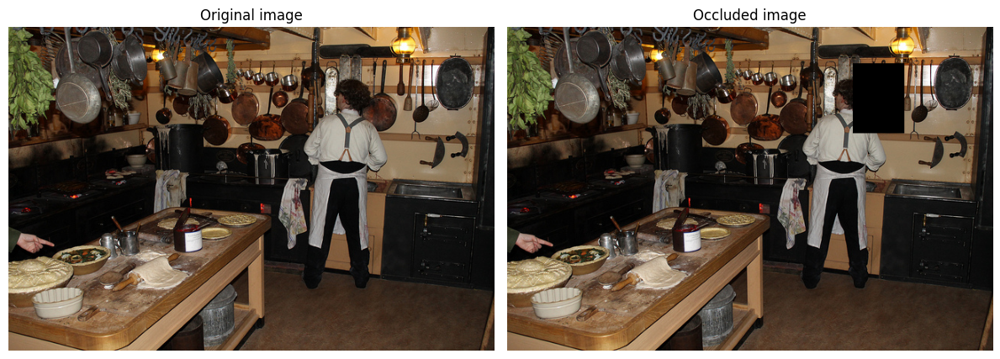

Occlusion rectangle (x, y, w, h): (455, 49, 68, 92)


In [67]:
# Visualize example occlusion

sample_img_id = img_ids[0]
sample_img_info = coco.loadImgs(sample_img_id)[0]
sample_image_path = os.path.join(images_dir, sample_img_info["file_name"])

sample_image = Image.open(sample_image_path).convert("RGB")
sample_occluded_image, occ_rect = add_random_occlusion(sample_image)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(sample_image)
plt.title("Original image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sample_occluded_image)
plt.title("Occluded image")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Occlusion rectangle (x, y, w, h):", occ_rect)

##### YOLO on occluded images

In [68]:
all_predictions_occluded = []

for img_id in img_ids:
    img_info = coco.loadImgs(img_id)[0]
    image_path = os.path.join(images_dir, img_info["file_name"])

    image = Image.open(image_path).convert("RGB")
    occluded_image, _ = add_random_occlusion(image)

    result = model.predict(
        source=occluded_image,
        conf=AP_MIN_CONF,
        device=device,
        verbose=False
    )[0]

    for box, cls_id, conf in zip(
        result.boxes.xyxy.cpu().numpy(),
        result.boxes.cls.cpu().numpy().astype(int),
        result.boxes.conf.cpu().numpy()
    ):
        category = model.names[int(cls_id)]

        if category in category_names:
            all_predictions_occluded.append({
                "image_id": img_id,
                "category": category,
                "confidence": float(conf),
                "box": [float(x) for x in box]
            })

print("Total collected predictions on occluded images:", len(all_predictions_occluded))

Total collected predictions on occluded images: 706807


In [69]:
df_all_predictions_occluded = pd.DataFrame(all_predictions_occluded)

df_ap_all_occluded = []

for iou_thr in iou_thresholds:
    df_ap, pr_curves_occluded = evaluate_ap_per_category(
        df_all_predictions=df_all_predictions_occluded,
        category_names=category_names,
        gt_boxes_by_image_and_cat=gt_boxes_by_image_and_cat,
        gt_count_per_cat=gt_count_per_cat,
        iou_threshold=iou_thr
    )
    
    df_ap_all_occluded.append(df_ap)

df_ap_all_occluded = pd.concat(df_ap_all_occluded, ignore_index=True)
df_ap_all_occluded

,category,iou_threshold,num_gt,num_predictions_above_threshold,TP,FP,FN,precision,recall,AP
0,airplane,0.50,143,137,103,34,40,0.751825,0.720280,0.788599
1,apple,0.50,239,124,52,72,187,0.419355,0.217573,0.212784
2,backpack,0.50,371,112,57,55,314,0.508929,0.153639,0.180373
3,banana,0.50,379,196,105,91,274,0.535714,0.277045,0.337915
4,baseball bat,0.50,146,91,49,42,97,0.538462,0.335616,0.346968
...,...,...,...,...,...,...,...,...,...,...
795,tv,0.95,288,413,36,377,252,0.087167,0.125000,0.052301
796,umbrella,0.95,413,328,35,293,378,0.106707,0.084746,0.037557
797,vase,0.95,277,217,12,205,265,0.055300,0.043321,0.021997
798,wine glass,0.95,343,160,18,142,325,0.112500,0.052478,0.022468


#### Results

In [70]:
df_category_metrics_occluded = select_metrics_at_iou(df_ap_all_occluded, iou_threshold=IOU_THRESHOLD)
df_category_metrics_occluded

,category,iou_threshold,num_gt,num_predictions_above_threshold,TP,FP,FN,precision,recall,AP
0,giraffe,0.5,232,230,186,44,46,0.808696,0.801724,0.850327
1,zebra,0.5,268,250,203,47,65,0.812000,0.757463,0.847474
2,train,0.5,190,187,144,43,46,0.770053,0.757895,0.809357
3,cat,0.5,202,214,165,49,37,0.771028,0.816832,0.801774
4,airplane,0.5,143,137,103,34,40,0.751825,0.720280,0.788599
...,...,...,...,...,...,...,...,...,...,...
75,book,0.5,1161,225,100,125,1061,0.444444,0.086133,0.170893
76,knife,0.5,326,98,45,53,281,0.459184,0.138037,0.153118
77,handbag,0.5,540,123,59,64,481,0.479675,0.109259,0.144978
78,spoon,0.5,253,70,30,40,223,0.428571,0.118577,0.144153


In [71]:
map_50_occluded, map_50_95_occluded = compute_map_scores(df_ap_all_occluded, map_iou=0.50)

print("Occluded mAP@50 =", round(map_50_occluded, 4))
print("Occluded mAP@50-95 =", round(map_50_95_occluded, 4))

Occluded mAP@50 = 0.481
Occluded mAP@50-95 = 0.3311


##### Comparison to non-noisy

In [72]:
# Compare original vs occluded AP summarized
comparison_summary_occluded = build_comparison_summary(
    original_scores=(map_50_og, map_50_95_og),
    variant_label="occluded",
    variant_scores=(map_50_occluded, map_50_95_occluded),
    extra_scores={"noisy": (map50_noisy, map50_95_noisy)}
)

print("Original vs Occluded summary (drop results are from original to occluded)")
comparison_summary_occluded

Original vs Compressed summary (drop results are from original to occluded)


,metric,original,occluded,noisy,absolute_drop,relative_drop_percent
0,mAP@50,0.508692,0.481029,0.337900,0.027663,5.438025
1,mAP@50-95,0.359912,0.331130,0.227521,0.028782,7.996903


In [73]:
# Compare original vs occluded AP per category
df_ap_compare_occluded = build_ap_drop_table(
    df_original_metrics=df_category_metrics,
    df_variant_metrics=df_category_metrics_occluded,
    variant_label="occluded"
)
df_ap_compare_occluded

,category,AP_original,AP_occluded,AP_drop
0,tv,0.708470,0.581810,0.126661
1,bear,0.813245,0.737971,0.075274
2,skateboard,0.639119,0.569627,0.069491
3,hot dog,0.453993,0.388113,0.065880
4,traffic light,0.408215,0.348569,0.059646
...,...,...,...,...
75,hair drier,0.006993,0.006494,0.000500
76,parking meter,0.571827,0.572392,-0.000564
77,oven,0.548780,0.550147,-0.001368
78,backpack,0.178198,0.180373,-0.002175


##### Graphs

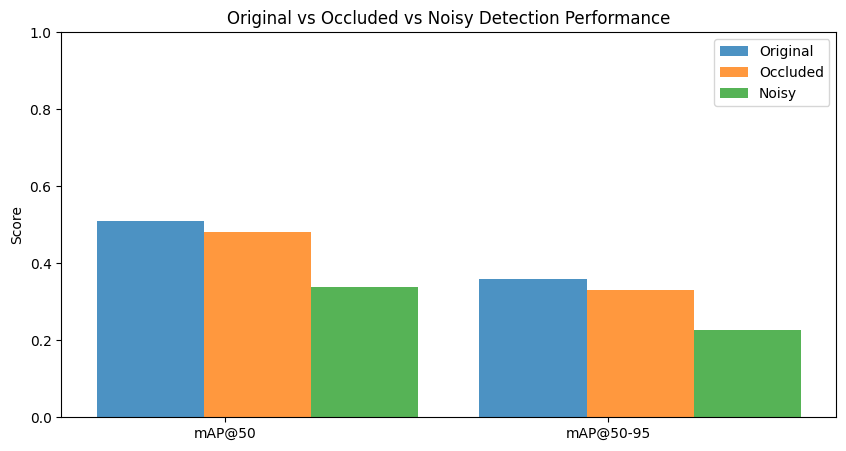

In [74]:
metrics = comparison_summary_occluded["metric"]
original = comparison_summary_occluded["original"]
occluded = comparison_summary_occluded["occluded"]
noisy = comparison_summary_occluded["noisy"]

x = np.arange(len(metrics))
width = 0.28

plt.figure(figsize=(10,5))
plt.bar(x - width*0.7, original, width=width, label="Original", alpha=0.8)
plt.bar(x + width*0.3, occluded, width=width, label="Occluded", alpha=0.8)
plt.bar(x + width*1.3, noisy, width=width, label="Noisy", alpha=0.8)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Original vs Occluded vs Noisy Detection Performance")
plt.legend()
plt.ylim(0, 1)
plt.show()

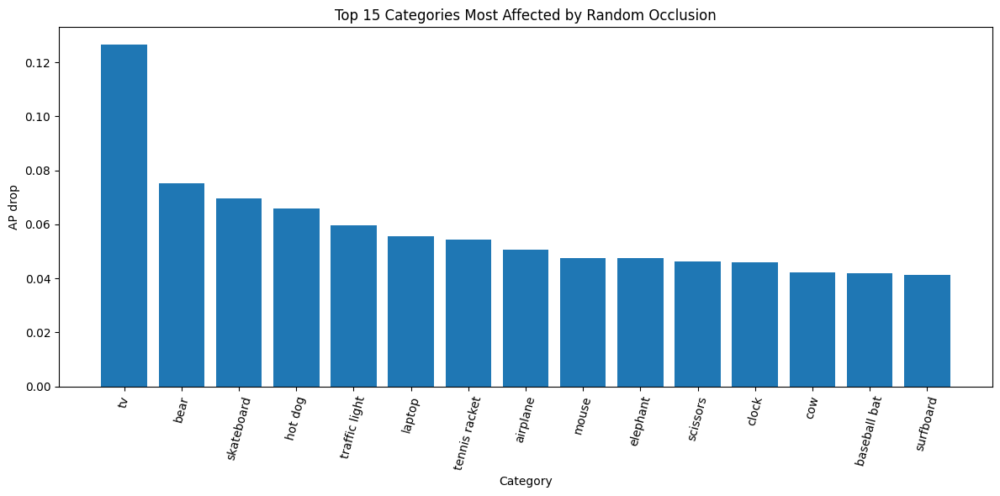

In [75]:
plot_ap_drop_bars(df_ap_compare_occluded, title="Random Occlusion", top_n=15)


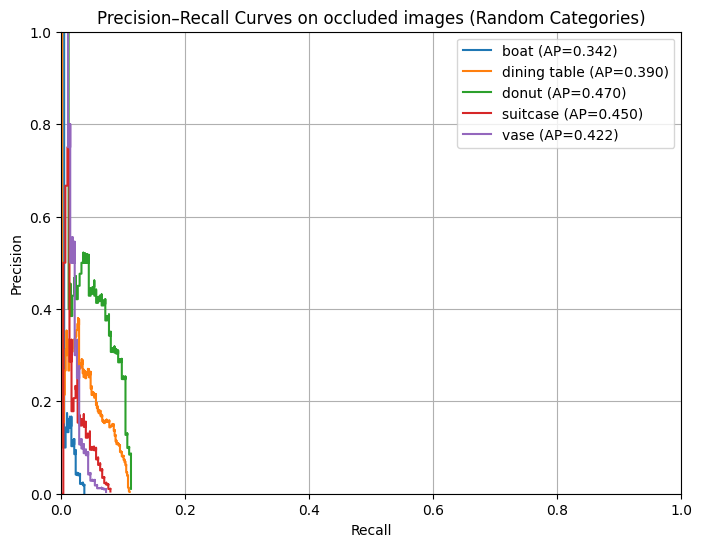

In [76]:
plot_pr_curves(
    pr_curves_occluded,
    category_names,
    df_category_metrics_occluded,
    title="Precision–Recall Curves on occluded images (Random Categories)",
    n_cats=5
)


### Conclusion

The results show that both distortions reduce detection performance, but their impact is different. **Additive noise causes a much larger degradation**, reducing mAP@50 from **0.509 to 0.336** and mAP@50-95 from **0.360 to 0.228** (about **35–37% drop**).

In comparison, **random occlusion has a smaller effect**, with mAP@50 decreasing from **0.509 to 0.477** and mAP@50-95 from **0.360 to 0.330** (about **6–8% drop**).

Some categories, such as **tv, skateboard, and keyboard**, are more affected by occlusion than others. Overall, the results indicate that the model is **more sensitive to noise than to partial occlusion**, suggesting that random pixel corruption harms detection more than partial object hiding.


## 5.3 - Effect of image compression

In this experiment, the images are compressed before being passed to the YOLOv8n detector, and the evaluation procedure from Section 4 is repeated.

As a compression method, we use **JPEG compression**.

***AI used [6]***

##### Helper + Example

In [77]:
# For easy compression we saved the image in memory as JPEG and reloaded it.

import io

def compress_image_jpeg(pil_image, quality=15):
    buffer = io.BytesIO()
    pil_image.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    compressed_image = Image.open(buffer).convert("RGB")
    return compressed_image

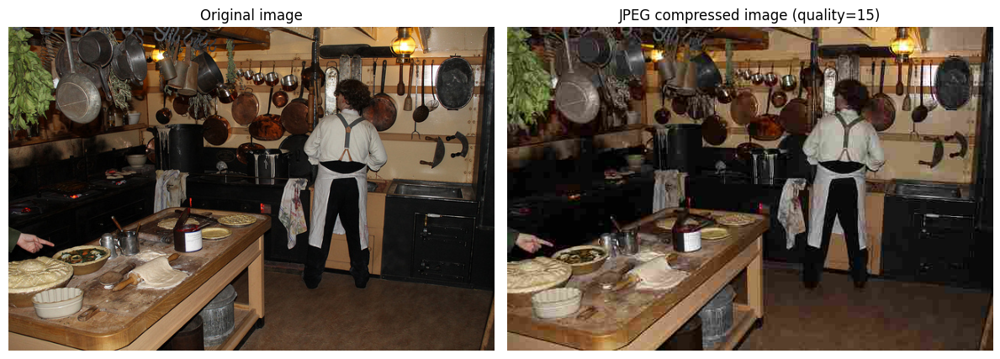

In [78]:
sample_img_id = img_ids[0]
sample_img_info = coco.loadImgs(int(sample_img_id))[0]
sample_image_path = os.path.join(images_dir, sample_img_info["file_name"])

sample_image = Image.open(sample_image_path).convert("RGB")
sample_compressed_image = compress_image_jpeg(sample_image)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(sample_image)
plt.title("Original image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sample_compressed_image)
plt.title(f"JPEG compressed image (quality=15)")
plt.axis("off")

plt.tight_layout()
plt.show()

##### YOLO on compressed images

In [79]:
all_predictions_compressed = []

for img_id in img_ids:
    img_info = coco.loadImgs(int(img_id))[0]
    image_path = os.path.join(images_dir, img_info["file_name"])

    image = Image.open(image_path).convert("RGB")
    compressed_image = compress_image_jpeg(image)

    result = model.predict(
        source=compressed_image,
        conf=AP_MIN_CONF,
        device=device,
        verbose=False
    )[0]

    if result.boxes is None:
        continue

    for box, cls_id, conf in zip(
        result.boxes.xyxy.cpu().numpy(),
        result.boxes.cls.cpu().numpy().astype(int),
        result.boxes.conf.cpu().numpy()
    ):
        category = model.names[int(cls_id)]

        if category in category_names:
            all_predictions_compressed.append({
                "image_id": int(img_id),
                "category": category,
                "confidence": float(conf),
                "box": [float(x) for x in box]
            })

print("Total predictions on compressed images:", len(all_predictions_compressed))

Total predictions on compressed images: 933745


In [80]:
df_all_predictions_compressed = pd.DataFrame(all_predictions_compressed)

df_ap_all_compressed = []

for iou_thr in iou_thresholds:
    df_ap, pr_curves_compressed = evaluate_ap_per_category(
        df_all_predictions=df_all_predictions_compressed,
        category_names=category_names,
        gt_boxes_by_image_and_cat=gt_boxes_by_image_and_cat,
        gt_count_per_cat=gt_count_per_cat,
        iou_threshold=iou_thr
    )
    
    df_ap_all_compressed.append(df_ap)

df_ap_all_compressed = pd.concat(df_ap_all_compressed, ignore_index=True)
df_ap_all_compressed

,category,iou_threshold,num_gt,num_predictions_above_threshold,TP,FP,FN,precision,recall,AP
0,airplane,0.50,143,168,77,91,66,0.458333,0.538462,0.519755
1,apple,0.50,239,22,12,10,227,0.545455,0.050209,0.102348
2,backpack,0.50,371,81,23,58,348,0.283951,0.061995,0.054135
3,banana,0.50,379,70,40,30,339,0.571429,0.105541,0.173942
4,baseball bat,0.50,146,68,34,34,112,0.500000,0.232877,0.238265
...,...,...,...,...,...,...,...,...,...,...
795,tv,0.95,288,239,22,217,266,0.092050,0.076389,0.026239
796,umbrella,0.95,413,311,21,290,392,0.067524,0.050847,0.018870
797,vase,0.95,277,152,9,143,268,0.059211,0.032491,0.008697
798,wine glass,0.95,343,68,5,63,338,0.073529,0.014577,0.004353


### Results

In [81]:
df_category_metrics_compressed = select_metrics_at_iou(df_ap_all_compressed, iou_threshold=IOU_THRESHOLD)
df_category_metrics_compressed

,category,iou_threshold,num_gt,num_predictions_above_threshold,TP,FP,FN,precision,recall,AP
0,zebra,0.5,268,231,193,38,75,0.835498,0.720149,0.816128
1,giraffe,0.5,232,164,142,22,90,0.865854,0.612069,0.704501
2,train,0.5,190,308,140,168,50,0.454545,0.736842,0.681555
3,fire hydrant,0.5,101,125,60,65,41,0.480000,0.594059,0.571939
4,bus,0.5,285,222,149,73,136,0.671171,0.522807,0.569419
...,...,...,...,...,...,...,...,...,...,...
75,handbag,0.5,540,51,18,33,522,0.352941,0.033333,0.053602
76,spoon,0.5,253,5,3,2,250,0.600000,0.011858,0.047146
77,remote,0.5,283,6,3,3,280,0.500000,0.010601,0.042470
78,knife,0.5,326,14,6,8,320,0.428571,0.018405,0.042128


In [82]:
map_50_compressed, map_50_95_compressed = compute_map_scores(df_ap_all_compressed, map_iou=0.50)

print("Compressed mAP@50 =", round(map_50_compressed, 4))
print("Compressed mAP@50-95 =", round(map_50_95_compressed, 4))

Compressed mAP@50 = 0.2739
Compressed mAP@50-95 = 0.1779


##### Comparison to non-noisy

In [83]:
comparison_summary_compressed = build_comparison_summary(
    original_scores=(map_50_og, map_50_95_og),
    variant_label="compressed",
    variant_scores=(map_50_compressed, map_50_95_compressed),
    extra_scores={
        "noisy": (map50_noisy, map50_95_noisy),
        "occluded": (map_50_occluded, map_50_95_occluded),
    },
)

print("Original vs Compressed summary (drop results are from original to compressed)")
comparison_summary_compressed

Original vs Compressed summary (drop results are from original to compressed)


,metric,original,compressed,noisy,occluded,absolute_drop,relative_drop_percent
0,mAP@50,0.508692,0.273887,0.337900,0.481029,0.234804,46.158499
1,mAP@50-95,0.359912,0.177928,0.227521,0.331130,0.181984,50.563447


In [84]:
df_ap_compare_compressed = build_ap_drop_table(
    df_original_metrics=df_category_metrics,
    df_variant_metrics=df_category_metrics_compressed,
    variant_label="compressed"
)
df_ap_compare_compressed.head(10)

,category,AP_original,AP_compressed,AP_drop
0,cat,0.834309,0.093362,0.740946
1,bear,0.813245,0.159765,0.653480
2,dog,0.681728,0.177339,0.504390
3,elephant,0.806120,0.341747,0.464373
4,toilet,0.769625,0.338938,0.430687
5,bed,0.603733,0.188257,0.415476
6,couch,0.575872,0.164327,0.411546
7,teddy bear,0.586916,0.176305,0.410611
8,mouse,0.689060,0.285678,0.403381
9,sheep,0.648032,0.258467,0.389565


##### Graphs

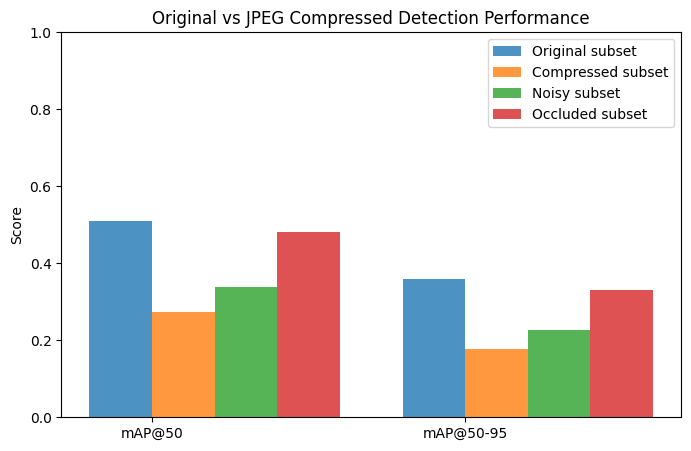

In [85]:
metrics = comparison_summary_compressed["metric"]
original_subset = comparison_summary_compressed["original"]
compressed_subset = comparison_summary_compressed["compressed"]
noisy_subset = comparison_summary_compressed["noisy"]
occluded_subset = comparison_summary_compressed["occluded"]

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(8,5))
plt.bar(x - width/2, original_subset, width, label="Original subset", alpha=0.8)
plt.bar(x + width/2, compressed_subset, width, label="Compressed subset", alpha=0.8)
plt.bar(x + width*1.5, noisy_subset, width, label="Noisy subset", alpha=0.8)
plt.bar(x + width*2.5, occluded_subset, width, label="Occluded subset", alpha=0.8)
plt.xticks(x, metrics)

plt.ylabel("Score")
plt.title("Original vs JPEG Compressed Detection Performance")
plt.legend()
plt.ylim(0, 1)
plt.show()




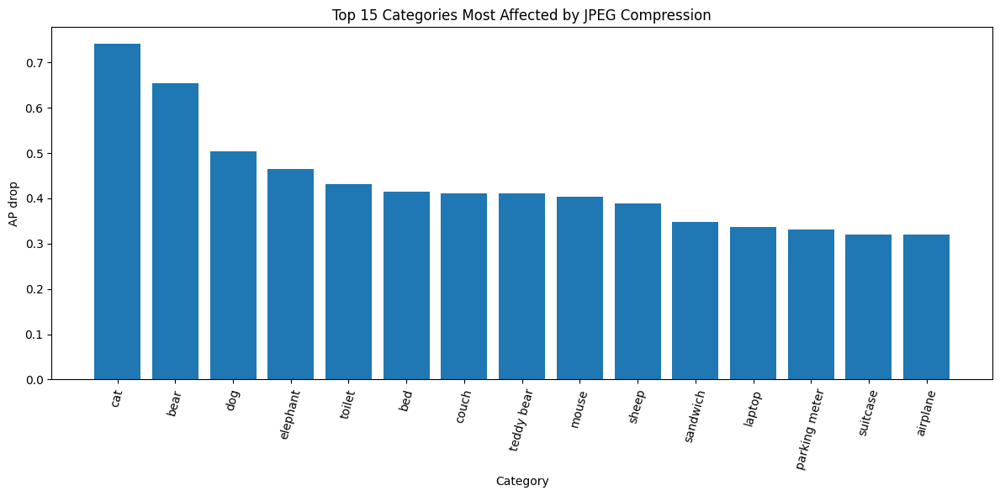

In [86]:
plot_ap_drop_bars(df_ap_compare_compressed, title="JPEG Compression", top_n=15)


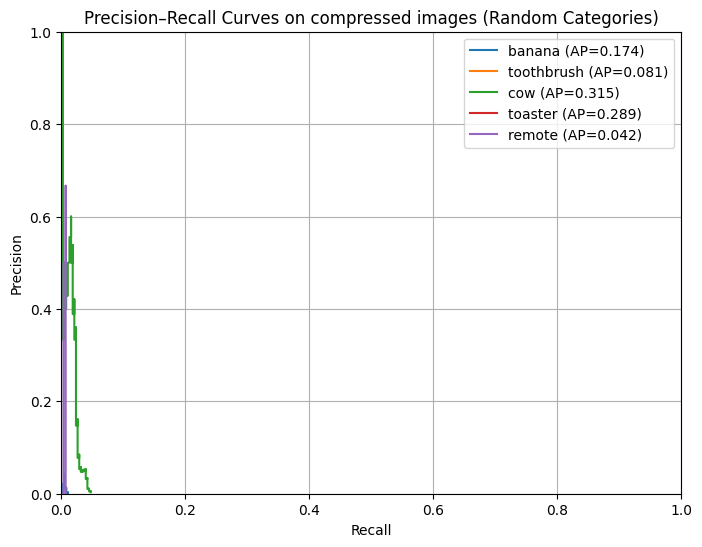

In [87]:
plot_pr_curves(
    pr_curves_compressed,
    category_names,
    df_category_metrics_compressed,
    title="Precision–Recall Curves on compressed images (Random Categories)",
    n_cats=5
)


### Conclusion

JPEG compression significantly reduces the detection performance of the model. The overall results show that **mAP@50 drops from 0.509 to 0.349** and **mAP@50-95 drops from 0.360 to 0.232**, which is about a **31-36% decrease**. This means the detector is strongly affected by compression artifacts.

Compared to the other distortions, JPEG compression has an effect that is **almost as severe as additive noise**, and much stronger than random occlusion. While occlusion caused only a small overall drop, compression and noise both caused major degradation.

The category-level results show that some classes are affected much more than others. The largest AP drops were observed for **cat, bear, dog, bed, and couch**, with especially large degradation for **cat**, where AP decreased by about **0.60**. This suggests that compression removes important visual details needed for reliable detection.

Overall, the results indicate that the model is **not robust to JPEG compression**, and that loss of image quality can severely harm both classification and localization performance.


## 5.4 - Demonstrating the robustness limits of YOLOv8n

In this section, a small number of images is used to demonstrate the robustness limits of YOLOv8n under the distortions examined in Sections 5.1-5.3.

For each distortion type, several increasing distortion levels are applied to the same image.  
The detector output is then inspected visually in order to identify the point at which the model begins to fail.

This analysis is qualitative and is intended to complement the quantitative evaluation from the previous subsections.

In [88]:
demo_img_ids = (
    df_image_stats[
        (df_image_stats["num_objects"] >= 5) &
        (df_image_stats["num_categories"] >= 3)
    ]
    .sort_values(["num_categories", "num_objects"], ascending=False)["image_id"]
    .tolist()
)

print("Number of demo images:", len(demo_img_ids))

Number of demo images: 1917


we didnt want all of thee images in the data set for this section because it would have a very long run time. Instead we only took image with 5 or more objects from 3 or more categories, **1917** images for this section.

***AI used [7]***

#### Helpers

In [89]:
def evaluate_distortion_level_on_subset(
    img_ids,
    distortion_fn,
    distortion_name,
    distortion_value,
    model,
    coco,
    images_dir,
    category_names,
    gt_boxes_by_image_and_cat,
    gt_count_per_cat,
    iou_thresholds,
    device
):
    all_predictions = []

    for img_id in img_ids:
        img_info = coco.loadImgs(int(img_id))[0]
        image_path = os.path.join(images_dir, img_info["file_name"])
        image = Image.open(image_path).convert("RGB")

        distorted_image = distortion_fn(image, distortion_value)

        result = model.predict(
            source=distorted_image,
            conf=AP_MIN_CONF,
            device=device,
            verbose=False
        )[0]

        if result.boxes is None:
            continue

        for box, cls_id, conf in zip(
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.cls.cpu().numpy().astype(int),
            result.boxes.conf.cpu().numpy()
        ):
            category = model.names[int(cls_id)]

            if category in category_names:
                all_predictions.append({
                    "image_id": int(img_id),
                    "category": category,
                    "confidence": float(conf),
                    "box": [float(x) for x in box]
                })

    df_all_predictions = pd.DataFrame(all_predictions)

    all_ap_tables = []

    for iou_thr in iou_thresholds:
        df_metrics, _ = evaluate_ap_per_category(
            df_all_predictions=df_all_predictions,
            category_names=category_names,
            gt_boxes_by_image_and_cat=gt_boxes_by_image_and_cat,
            gt_count_per_cat=gt_count_per_cat,
            iou_threshold=iou_thr
        )
        all_ap_tables.append(df_metrics)

    df_ap_all = pd.concat(all_ap_tables, ignore_index=True)

    df_category_metrics = (
        df_ap_all[df_ap_all["iou_threshold"] == IOU_THRESHOLD]
        .sort_values("AP", ascending=False)
        .reset_index(drop=True)
    )

    map_50 = df_ap_all[df_ap_all["iou_threshold"] == 0.50]["AP"].mean()
    map_50_95 = df_ap_all["AP"].mean()

    summary = pd.DataFrame({
        "distortion_type": [distortion_name],
        "distortion_level": [distortion_value],
        "mAP@50": [map_50],
        "mAP@50-95": [map_50_95]
    })

    return df_all_predictions, df_category_metrics, df_ap_all, summary

In [90]:
def apply_noise(image, std):
    return add_gaussian_noise(image, mean=0, std=std)

def apply_jpeg_compression(image, quality):
    return compress_image_jpeg(image, quality=quality)

def apply_occlusion(image, min_max_frac):
    min_frac, max_frac = min_max_frac
    occluded_image, _ = add_random_occlusion(image, min_frac=min_frac, max_frac=max_frac)
    return occluded_image

#### Category names for test subset

In [91]:
demo_category_names = sorted(df_annotations["category_name"].unique())

gt_boxes_by_image_and_cat_demo = {}
gt_count_per_cat_demo = {cat: 0 for cat in demo_category_names}

for img_id in demo_img_ids:
    ann_ids = coco.getAnnIds(imgIds=[int(img_id)])
    anns = coco.loadAnns(ann_ids)

    gt_boxes_by_image_and_cat_demo[int(img_id)] = {}

    for ann in anns:
        cat_name = cat_id_to_name[ann["category_id"]]
        x, y, w, h = ann["bbox"]
        box_xyxy = [x, y, x + w, y + h]

        if cat_name not in gt_boxes_by_image_and_cat_demo[int(img_id)]:
            gt_boxes_by_image_and_cat_demo[int(img_id)][cat_name] = []

        gt_boxes_by_image_and_cat_demo[int(img_id)][cat_name].append(box_xyxy)
        gt_count_per_cat_demo[cat_name] += 1

### Run YOLO

**Gaussian Noise**

In [92]:
noise_levels = [5, 15, 30, 50, 70]
noise_summaries = []

for std in noise_levels:
    df_all_pred_noise, df_cat_metrics_noise, df_ap_all_noise, summary_noise = evaluate_distortion_level_on_subset(
        img_ids=demo_img_ids,
        distortion_fn=apply_noise,
        distortion_name="noise",
        distortion_value=std,
        model=model,
        coco=coco,
        images_dir=images_dir,
        category_names=demo_category_names,
        gt_boxes_by_image_and_cat=gt_boxes_by_image_and_cat_demo,
        gt_count_per_cat=gt_count_per_cat_demo,
        iou_thresholds=iou_thresholds,
        device=device
    )

    summary_noise["mean_precision"] = df_cat_metrics_noise["precision"].mean()
    summary_noise["mean_recall"] = df_cat_metrics_noise["recall"].mean()
    summary_noise["mean_AP"] = df_cat_metrics_noise["AP"].mean()

    noise_summaries.append(summary_noise)

df_noise_robustness = pd.concat(noise_summaries, ignore_index=True)
df_noise_robustness

,distortion_type,distortion_level,mAP@50,mAP@50-95,mean_precision,mean_recall,mean_AP
0,noise,5,0.426264,0.290739,0.617028,0.370204,0.426264
1,noise,15,0.364191,0.241352,0.632220,0.303058,0.364191
2,noise,30,0.233725,0.149502,0.568891,0.183428,0.233725
3,noise,50,0.096424,0.060931,0.498671,0.068717,0.096424
4,noise,70,0.030300,0.018604,0.343447,0.016503,0.030300


**JPEG**

In [93]:
qualities = [70, 50, 30, 15, 5]
jpeg_summaries = []

for quality in qualities:
    df_all_pred_jpeg, df_cat_metrics_jpeg, df_ap_all_jpeg, summary_jpeg = evaluate_distortion_level_on_subset(
        img_ids=demo_img_ids,
        distortion_fn=apply_jpeg_compression,
        distortion_name="jpeg_compression",
        distortion_value=quality,
        model=model,
        coco=coco,
        images_dir=images_dir,
        category_names=demo_category_names,
        gt_boxes_by_image_and_cat=gt_boxes_by_image_and_cat_demo,
        gt_count_per_cat=gt_count_per_cat_demo,
        iou_thresholds=iou_thresholds,
        device=device
    )

    summary_jpeg["mean_precision"] = df_cat_metrics_jpeg["precision"].mean()
    summary_jpeg["mean_recall"] = df_cat_metrics_jpeg["recall"].mean()
    summary_jpeg["mean_AP"] = df_cat_metrics_jpeg["AP"].mean()

    jpeg_summaries.append(summary_jpeg)

df_jpeg_robustness = pd.concat(jpeg_summaries, ignore_index=True)
df_jpeg_robustness

,distortion_type,distortion_level,mAP@50,mAP@50-95,mean_precision,mean_recall,mean_AP
0,jpeg_compression,70,0.419492,0.284017,0.623652,0.364197,0.419492
1,jpeg_compression,50,0.399831,0.266497,0.614754,0.345056,0.399831
2,jpeg_compression,30,0.362451,0.236678,0.601198,0.307637,0.362451
3,jpeg_compression,15,0.243001,0.153671,0.552319,0.198213,0.243001
4,jpeg_compression,5,0.042349,0.025983,0.277262,0.033696,0.042349


**Occlusion**

In [ ]:
occ_fracs = [(0.15,0.15), (0.30,0.30), (0.45,0.45), (0.60,0.60), (0.75,0.75)]
occlusion_summaries = []

for occ_val in occ_fracs:
    df_all_pred_occ, df_cat_metrics_occ, df_ap_all_occ, summary_occ = evaluate_distortion_level_on_subset(
        img_ids=demo_img_ids,
        distortion_fn=apply_occlusion,
        distortion_name="random_occlusion",
        distortion_value=occ_val,
        model=model,
        coco=coco,
        images_dir=images_dir,
        category_names=demo_category_names,
        gt_boxes_by_image_and_cat=gt_boxes_by_image_and_cat_demo,
        gt_count_per_cat=gt_count_per_cat_demo,
        iou_thresholds=iou_thresholds,
        device=device
    )

    summary_occ["mean_precision"] = df_cat_metrics_occ["precision"].mean()
    summary_occ["mean_recall"] = df_cat_metrics_occ["recall"].mean()
    summary_occ["mean_AP"] = df_cat_metrics_occ["AP"].mean()

    occlusion_summaries.append(summary_occ)

df_occlusion_robustness = pd.concat(occlusion_summaries, ignore_index=True)
df_occlusion_robustness

### Results

In [ ]:
df_robustness_comparison = pd.concat([
    df_noise_robustness,
    df_jpeg_robustness,
    df_occlusion_robustness
], ignore_index=True)

df_robustness_comparison = df_robustness_comparison[
    ["distortion_type", "distortion_level", "mean_precision", "mean_recall", "mean_AP", "mAP@50", "mAP@50-95"]
].sort_values(["mean_AP"], ascending=False).reset_index(drop=True)

df_robustness_comparison

,distortion_type,distortion_level,mean_precision,mean_recall,mean_AP,mAP@50,mAP@50-95
0,noise,5,0.618844,0.370328,0.425870,0.425870,0.289509
1,jpeg_compression,70,0.623652,0.364197,0.419492,0.419492,0.284017
2,random_occlusion,"(0.15, 0.15)",0.603979,0.372047,0.417153,0.417153,0.282370
3,jpeg_compression,50,0.614754,0.345056,0.399831,0.399831,0.266497
4,noise,15,0.621675,0.302284,0.363634,0.363634,0.241945
5,random_occlusion,"(0.3, 0.3)",0.563568,0.334514,0.363564,0.363564,0.235450
6,jpeg_compression,30,0.601198,0.307637,0.362451,0.362451,0.236678
7,random_occlusion,"(0.45, 0.45)",0.516608,0.249170,0.253957,0.253957,0.151854
8,jpeg_compression,15,0.552319,0.198213,0.243001,0.243001,0.153671
9,noise,30,0.595725,0.183995,0.234890,0.234890,0.150675


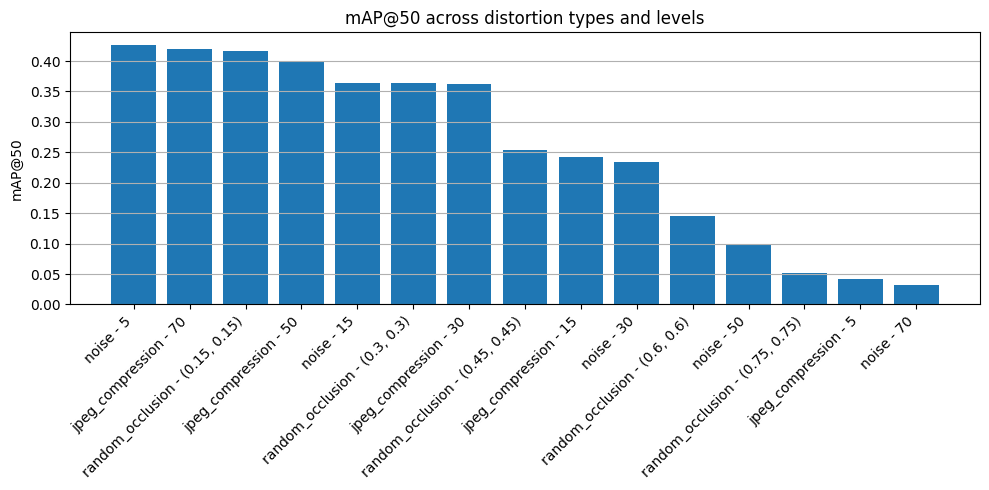

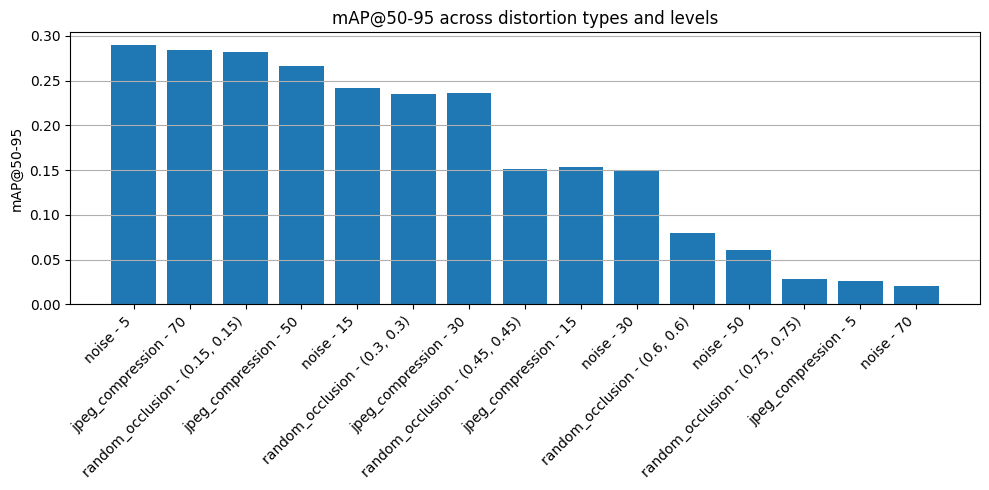

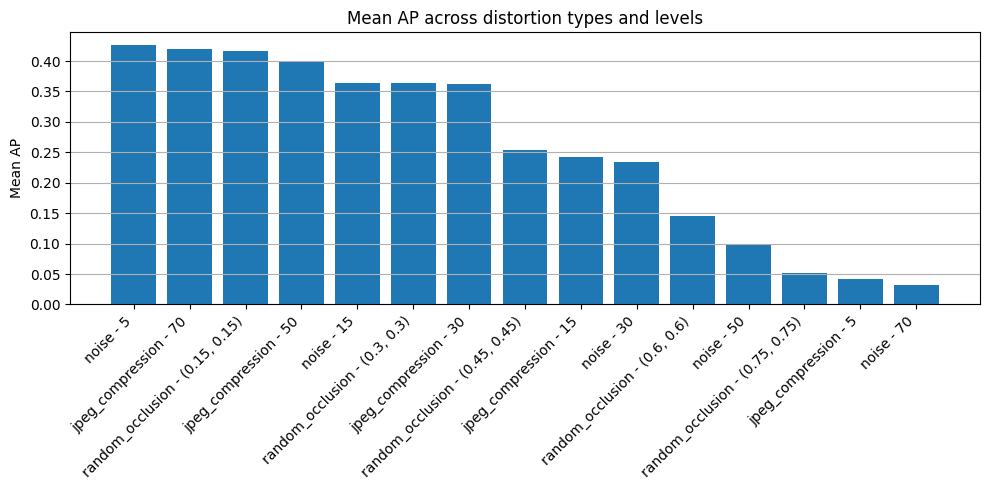

In [ ]:
plt.figure(figsize=(10, 5))

labels = df_robustness_comparison["distortion_type"] + " - " + df_robustness_comparison["distortion_level"].astype(str)
plt.bar(labels, df_robustness_comparison["mAP@50"])

plt.xticks(rotation=45, ha="right")
plt.ylabel("mAP@50")
plt.title("mAP@50 across distortion types and levels")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

labels = df_robustness_comparison["distortion_type"] + " - " + df_robustness_comparison["distortion_level"].astype(str)
plt.bar(labels, df_robustness_comparison["mAP@50-95"])

plt.xticks(rotation=45, ha="right")
plt.ylabel("mAP@50-95")
plt.title("mAP@50-95 across distortion types and levels")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

labels = df_robustness_comparison["distortion_type"] + " - " + df_robustness_comparison["distortion_level"].astype(str)
plt.bar(labels, df_robustness_comparison["mean_AP"])

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean AP")
plt.title("Mean AP across distortion types and levels")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

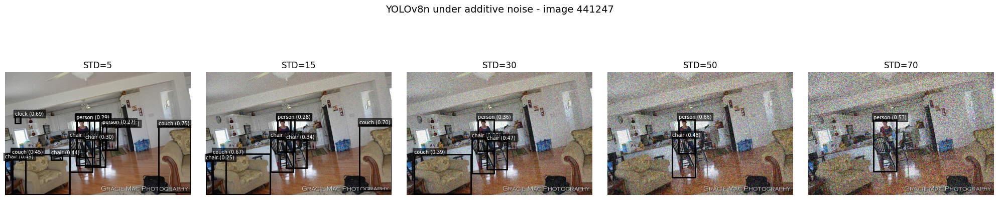

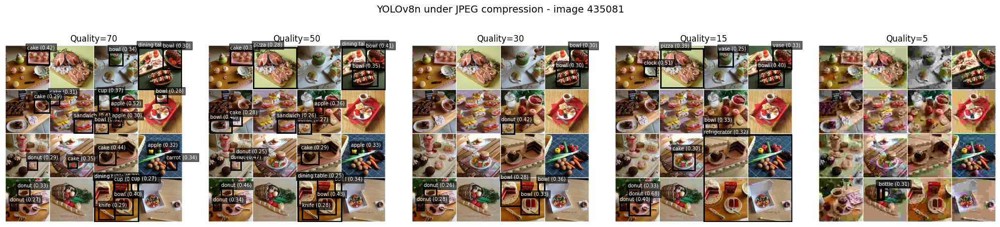

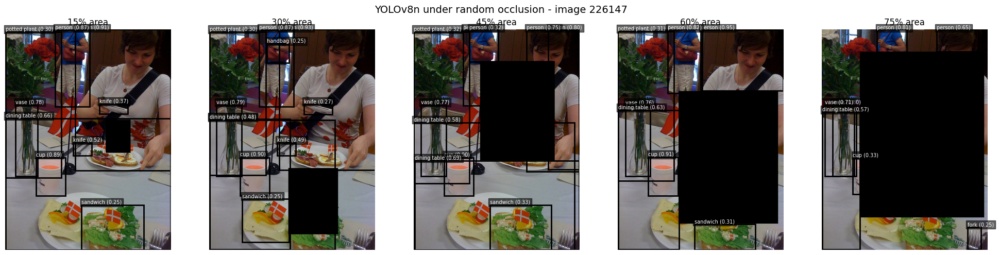

In [ ]:
# Choose which demo images to use
noise_img_id = demo_img_ids[0]
jpeg_img_id = demo_img_ids[1]
occlusion_img_id = demo_img_ids[2]

# Distortion levels
noise_levels = [5, 15, 30, 50, 70]
jpeg_levels = [70, 50, 30, 15, 5]          # lower quality = stronger compression
occlusion_levels = [(0.15, 0.15), (0.30, 0.30), (0.45, 0.45), (0.60, 0.60), (0.75, 0.75)]

# Helper: run YOLO on PIL image
def run_yolo_on_pil_image(pil_image, model, device, conf=0.25):
    return model.predict(
        source=pil_image,
        conf=conf,
        device=device,
        verbose=False
    )[0]

# Helper: draw predictions
def draw_yolo_predictions_on_axis(ax, pil_image, result, model, title=""):
    ax.imshow(np.array(pil_image))
    ax.axis("off")
    ax.set_title(title)

    if result.boxes is None or len(result.boxes) == 0:
        return

    boxes = result.boxes.xyxy.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    for box, cls_id, conf in zip(boxes, classes, confs):
        x1, y1, x2, y2 = box

        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)

        ax.text(
            x1,
            max(y1 - 3, 0),
            f"{model.names[int(cls_id)]} ({conf:.2f})",
            color="white",
            fontsize=7,
            bbox=dict(facecolor="black", alpha=0.6, pad=2)
        )

# Helper: generic grid
def show_distortion_grid(img_id, levels, distortion_fn, title_prefix, level_to_title):
    img_info = coco.loadImgs(int(img_id))[0]
    image_path = os.path.join(images_dir, img_info["file_name"])
    image = Image.open(image_path).convert("RGB")

    fig, axes = plt.subplots(1, len(levels), figsize=(4 * len(levels), 5))

    for ax, level in zip(axes, levels):
        distorted_image = distortion_fn(image, level)
        result = run_yolo_on_pil_image(distorted_image, model, device, conf=0.25)
        draw_yolo_predictions_on_axis(
            ax,
            distorted_image,
            result,
            model,
            title=level_to_title(level)
        )

    plt.suptitle(f"{title_prefix} - image {img_id}", fontsize=14)
    plt.tight_layout()
    plt.show()


# Show additive noise example
show_distortion_grid(
    img_id=noise_img_id,
    levels=noise_levels,
    distortion_fn=apply_noise,
    title_prefix="YOLOv8n under additive noise",
    level_to_title=lambda level: f"STD={level}"
)

# Show JPEG compression example
show_distortion_grid(
    img_id=jpeg_img_id,
    levels=jpeg_levels,
    distortion_fn=apply_jpeg_compression,
    title_prefix="YOLOv8n under JPEG compression",
    level_to_title=lambda level: f"Quality={level}"
)

# Show occlusion example
show_distortion_grid(
    img_id=occlusion_img_id,
    levels=occlusion_levels,
    distortion_fn=apply_occlusion,
    title_prefix="YOLOv8n under random occlusion",
    level_to_title=lambda level: f"{int(level[0] * 100)}% area"
)

### Conclusion

The results show that YOLOv8n is reasonably robust to **mild distortions**, but its performance drops clearly as distortion strength increases. The best results were obtained for **noise STD=5**, **JPEG quality 70**, and **15% occlusion**, where detection performance remained relatively high.

As the distortions became stronger, all metrics decreased. The sharpest degradation was observed under **strong additive noise** and **strong JPEG compression**, while **occlusion caused a more gradual decline**. For example, `mAP@50` dropped from about **0.426 to 0.033** for noise, from **0.419 to 0.042** for JPEG compression, and from **0.417 to 0.052** for occlusion.

Overall, the visual examples and the quantitative results are consistent: YOLOv8n can still detect objects under mild distortion, but under severe degradation it quickly loses accuracy and misses many objects.


# 6.
## Repeating Sections 4 and 5 with multiple YOLOv8 models

In this section, we repeat the Section 4/5 evaluation pipeline for multiple models and compare results.

Compared models:
- YOLOv8n
- YOLOv8s
- YOLOv8m
- YOLOv8i (mapped to YOLOv8l weights, since Ultralytics provides n/s/m/l/x)
- YOLOv8x

### 6.1 Setup and subset preparation
We use a fixed subset of validation images for a fair and practical runtime comparison.

In [ ]:

section6_model_paths = {
    "yolov8n": "yolov8n.pt",
    "yolov8s": "yolov8s.pt",
    "yolov8m": "yolov8m.pt",
    "yolov8l": "yolov8l.pt",
    "yolov8x": "yolov8x.pt",
}

missing_weights = [w for w in section6_model_paths.values() if not os.path.exists(w)]
if missing_weights:
    raise FileNotFoundError(f"Missing model weights: {missing_weights}")

print("Models to evaluate:", list(section6_model_paths.keys()))
print("Note: yolov8i uses yolov8l.pt as the closest available variant.")

SECTION6_SUBSET_SIZE = 150
random.seed(42)
section6_img_ids = random.sample(list(img_ids), SECTION6_SUBSET_SIZE)
print("Section 6 subset size:", len(section6_img_ids))

Models to evaluate: ['yolov8n', 'yolov8s', 'yolov8m', 'yolov8i', 'yolov8x']
Note: yolov8i uses yolov8l.pt as the closest available variant.
Section 6 subset size: 150


In [96]:
# Build subset GT structures
section6_gt_boxes = {}
section6_gt_count = {cat: 0 for cat in category_names}

for img_id in section6_img_ids:
    ann_ids = coco.getAnnIds(imgIds=[int(img_id)])
    anns_img = coco.loadAnns(ann_ids)
    section6_gt_boxes[int(img_id)] = {}

    for ann in anns_img:
        cat_name = cat_id_to_name[ann["category_id"]]
        x, y, w, h = ann["bbox"]
        box = [x, y, x + w, y + h]
        section6_gt_boxes[int(img_id)].setdefault(cat_name, []).append(box)
        section6_gt_count[cat_name] += 1

section6_category_names = [cat for cat, count in section6_gt_count.items() if count > 0]
print("Categories in section 6 subset:", len(section6_category_names))

Categories in section 6 subset: 75


### 6.2 Repeat Section 4.1: single-image qualitative comparison

Chosen image: 261982


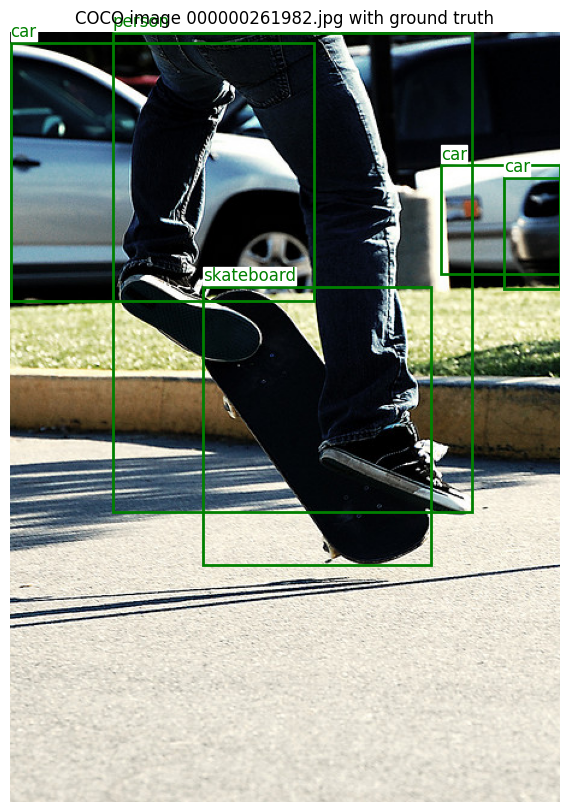

In [100]:
# Choose a representative image from subset (rich in objects and categories)
section6_image_stats = []
for img_id in section6_img_ids:
    anns_img = coco.loadAnns(coco.getAnnIds(imgIds=[int(img_id)]))
    section6_image_stats.append({
        "image_id": int(img_id),
        "num_objects": len(anns_img),
        "num_categories": len(set(a["category_id"] for a in anns_img)),
    })

df_section6_image_stats = pd.DataFrame(section6_image_stats)
section6_candidate_images = df_section6_image_stats[
    (df_section6_image_stats["num_objects"] >= 5) &
    (df_section6_image_stats["num_categories"] >= 3)
]
section6_chosen_img_id = int(section6_candidate_images.iloc[0]["image_id"])

img_info = coco.loadImgs(section6_chosen_img_id)[0]
response = requests.get(img_info["coco_url"], timeout=30)
response.raise_for_status()
section6_image = Image.open(BytesIO(response.content)).convert("RGB")
section6_anns = coco.loadAnns(coco.getAnnIds(imgIds=[section6_chosen_img_id]))

print("Chosen image:", section6_chosen_img_id)
show_coco_image_with_gt(coco, section6_chosen_img_id, cat_id_to_name, box_color='green')

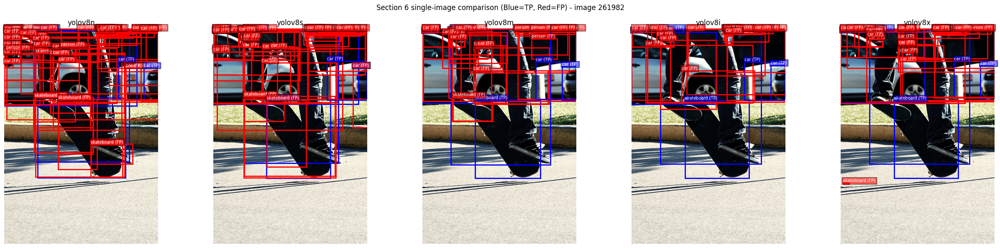

In [101]:
# Load models and compare TP/FP predictions on one image
section6_models = {name: YOLO(path) for name, path in section6_model_paths.items()}

def section6_get_prediction_statuses(result, anns, model, iou_threshold=0.5):
    pred_rows = []

    if result.boxes is not None and len(result.boxes) > 0:
        for box, cls_id, conf in zip(
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.cls.cpu().numpy().astype(int),
            result.boxes.conf.cpu().numpy(),
        ):
            pred_rows.append({
                "category": model.names[int(cls_id)],
                "confidence": float(conf),
                "x1": float(box[0]),
                "y1": float(box[1]),
                "x2": float(box[2]),
                "y2": float(box[3]),
            })

    df_preds = pd.DataFrame(pred_rows)
    if df_preds.empty:
        return df_preds, []

    df_preds = df_preds.sort_values("confidence", ascending=False).reset_index(drop=True)

    gt_by_cat = {}
    for ann in anns:
        cat_name = cat_id_to_name[ann["category_id"]]
        x, y, w, h = ann["bbox"]
        gt_box = [x, y, x + w, y + h]
        gt_by_cat.setdefault(cat_name, []).append({"box": gt_box, "matched": False})

    statuses = []
    for _, row in df_preds.iterrows():
        pred_box = [row.x1, row.y1, row.x2, row.y2]
        best_iou = 0
        best_gt_idx = None

        for gt_idx, gt in enumerate(gt_by_cat.get(row.category, [])):
            if gt["matched"]:
                continue
            iou = compute_iou(pred_box, gt["box"])
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_gt_idx is not None and best_iou >= iou_threshold:
            gt_by_cat[row.category][best_gt_idx]["matched"] = True
            statuses.append("TP")
        else:
            statuses.append("FP")

    return df_preds, statuses

fig, axes = plt.subplots(1, len(section6_models), figsize=(5 * len(section6_models), 6))
if len(section6_models) == 1:
    axes = [axes]

for ax, (model_name, model_obj) in zip(axes, section6_models.items()):
    result = model_obj.predict(source=section6_image, conf=AP_MIN_CONF, device=device, verbose=False)[0]
    df_preds_img, statuses = section6_get_prediction_statuses(result, section6_anns, model_obj, IOU_THRESHOLD)

    ax.imshow(section6_image)
    ax.axis("off")
    ax.set_title(model_name)

    for i, row in df_preds_img.iterrows():
        color = "blue" if statuses[i] == "TP" else "red"
        rect = plt.Rectangle((row.x1, row.y1), row.x2 - row.x1, row.y2 - row.y1, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
        ax.text(row.x1, max(row.y1 - 3, 0), f"{row.category} ({statuses[i]})", color="white", fontsize=7, bbox=dict(facecolor=color, alpha=0.6, pad=2))

plt.suptitle(f"Section 6 single-image comparison (Blue=TP, Red=FP) - image {section6_chosen_img_id}")
plt.tight_layout()
plt.show()

### 6.3 Repeat Sections 4.2/4.3 and 5 for each model
We evaluate each model under clean, noise, occlusion, and JPEG compression using the same subset.

In [ ]:
def section6_collect_predictions(model_obj, img_id_list, transform_fn):
    all_predictions_local = []

    for img_id in img_id_list:
        img_info = coco.loadImgs(int(img_id))[0]
        image_path = os.path.join(images_dir, img_info["file_name"])
        if not os.path.exists(image_path):
            continue

        image = Image.open(image_path).convert("RGB")
        image_in = transform_fn(image)

        result = model_obj.predict(source=image_in, conf=AP_MIN_CONF, device=device, verbose=False)[0]
        if result.boxes is None or len(result.boxes) == 0:
            continue

        for box, cls_id, conf in zip(
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.cls.cpu().numpy().astype(int),
            result.boxes.conf.cpu().numpy(),
        ):
            cat = model_obj.names[int(cls_id)]
            if cat in section6_category_names:
                all_predictions_local.append({
                    "image_id": int(img_id),
                    "category": cat,
                    "confidence": float(conf),
                    "box": [float(x) for x in box],
                })

    return pd.DataFrame(all_predictions_local)


def section6_evaluate_predictions(df_preds_local):
    if df_preds_local.empty:
        return pd.DataFrame(), pd.DataFrame(), 0.0, 0.0

    all_ap_tables = []
    for iou_thr in iou_thresholds:
        df_metrics_tmp, _ = evaluate_ap_per_category(
            df_all_predictions=df_preds_local,
            category_names=section6_category_names,
            gt_boxes_by_image_and_cat=section6_gt_boxes,
            gt_count_per_cat=section6_gt_count,
            iou_threshold=iou_thr,
        )
        all_ap_tables.append(df_metrics_tmp)

    df_ap_all_local = pd.concat(all_ap_tables, ignore_index=True)
    df_metrics_main_local = select_metrics_at_iou(df_ap_all_local, iou_threshold=IOU_THRESHOLD)
    map50_local, map50_95_local = compute_map_scores(df_ap_all_local, map_iou=0.50)

    return df_ap_all_local, df_metrics_main_local, map50_local, map50_95_local


section6_conditions = {
    "clean": lambda im: im,
    "noise_std25": lambda im: add_gaussian_noise(im, mean=0, std=25),
    "occlusion_15-30pct": lambda im: apply_occlusion(im, (0.15, 0.30)),
    "jpeg_q15": lambda im: compress_image_jpeg(im, quality=15),
}

section6_rows = []
for model_name, model_obj in section6_models.items():
    for condition_name, condition_fn in section6_conditions.items():
        df_preds_local = section6_collect_predictions(model_obj, section6_img_ids, condition_fn)
        df_ap_all_local, df_metrics_main_local, map50_local, map50_95_local = section6_evaluate_predictions(df_preds_local)

        mean_precision_local = df_metrics_main_local["precision"].mean() if not df_metrics_main_local.empty else 0.0
        mean_recall_local = df_metrics_main_local["recall"].mean() if not df_metrics_main_local.empty else 0.0
        mean_ap_local = df_metrics_main_local["AP"].mean() if not df_metrics_main_local.empty else 0.0

        section6_rows.append({
            "model": model_name,
            "condition": condition_name,
            "num_predictions": int(len(df_preds_local)),
            "mean_precision": float(mean_precision_local),
            "mean_recall": float(mean_recall_local),
            "mean_AP": float(mean_ap_local),
            "mAP@50": float(map50_local),
            "mAP@50-95": float(map50_95_local),
        })

df_section6_results = pd.DataFrame(section6_rows)
df_section6_results.sort_values(["condition", "mAP@50"], ascending=[True, False]).reset_index(drop=True)

,model,condition,num_predictions,mean_precision,mean_recall,mean_AP,mAP@50,mAP@50-95
0,yolov8x,clean,11433,0.747856,0.706801,0.735922,0.735922,0.591995
1,yolov8i,clean,12296,0.737805,0.688069,0.714617,0.714617,0.578018
2,yolov8m,clean,15657,0.672733,0.659393,0.691537,0.691537,0.550345
3,yolov8s,clean,18266,0.651215,0.586904,0.632639,0.632639,0.481904
4,yolov8n,clean,21500,0.599525,0.476995,0.551681,0.551681,0.415494
5,yolov8i,jpeg_q15,32696,0.559201,0.363405,0.432937,0.432937,0.314736
6,yolov8m,jpeg_q15,36616,0.492034,0.356214,0.420075,0.420075,0.300015
7,yolov8x,jpeg_q15,38293,0.523787,0.349997,0.414823,0.414823,0.287984
8,yolov8s,jpeg_q15,26822,0.503388,0.309527,0.369768,0.369768,0.259510
9,yolov8n,jpeg_q15,27964,0.434334,0.222625,0.292737,0.292737,0.215350


In [105]:
# Comparison tables
print("Best model per condition by mAP@50")
display(
    df_section6_results.loc[
        df_section6_results.groupby("condition")["mAP@50"].idxmax(),
        ["condition", "model", "mAP@50", "mAP@50-95", "mean_AP"],
    ].sort_values("condition")
)

print("Pivot table: mAP@50")
display(df_section6_results.pivot(index="model", columns="condition", values="mAP@50"))

print("Pivot table: mAP@50-95")
display(df_section6_results.pivot(index="model", columns="condition", values="mAP@50-95"))

Best model per condition by mAP@50


,condition,model,mAP@50,mAP@50-95,mean_AP
16,clean,yolov8x,0.735922,0.591995,0.735922
15,jpeg_q15,yolov8i,0.432937,0.314736,0.432937
17,noise_std25,yolov8x,0.623644,0.479205,0.623644
14,occlusion_30pct,yolov8i,0.627821,0.490445,0.627821


Pivot table: mAP@50


condition,clean,jpeg_q15,noise_std25,occlusion_30pct
model,,,,
yolov8i,0.714617,0.432937,0.617248,0.627821
yolov8m,0.691537,0.420075,0.617006,0.608985
yolov8n,0.551681,0.292737,0.362162,0.453179
yolov8s,0.632639,0.369768,0.502093,0.517822
yolov8x,0.735922,0.414823,0.623644,0.624720


Pivot table: mAP@50-95


condition,clean,jpeg_q15,noise_std25,occlusion_30pct
model,,,,
yolov8i,0.578018,0.314736,0.480585,0.490445
yolov8m,0.550345,0.300015,0.472065,0.467040
yolov8n,0.415494,0.215350,0.264235,0.321972
yolov8s,0.481904,0.259510,0.369836,0.377520
yolov8x,0.591995,0.287984,0.479205,0.471962


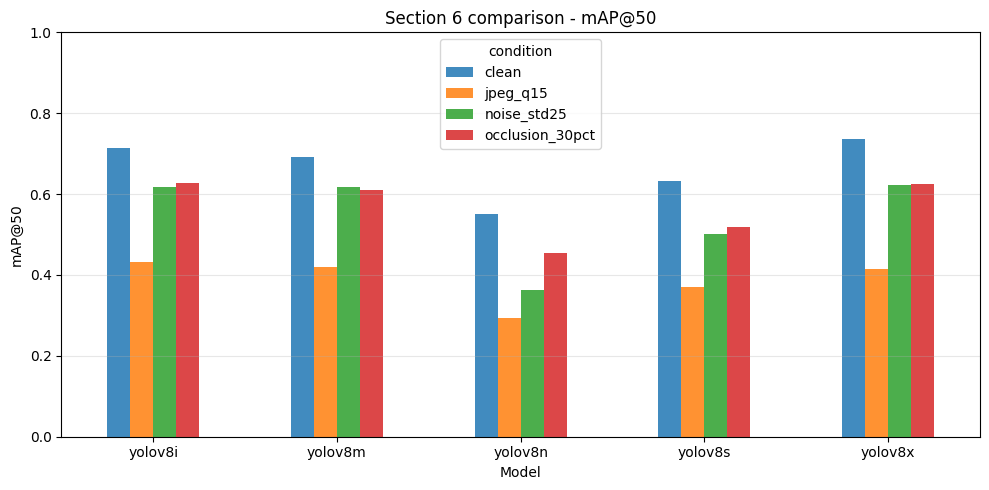

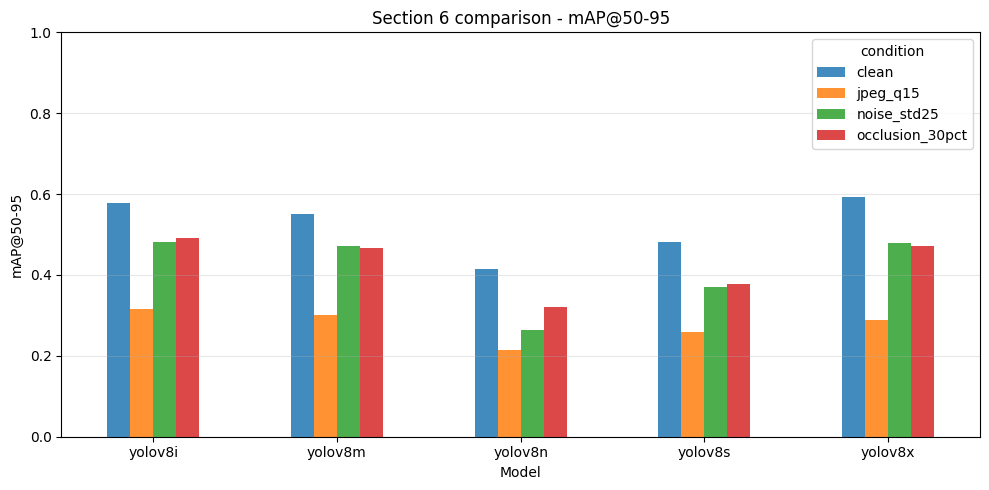

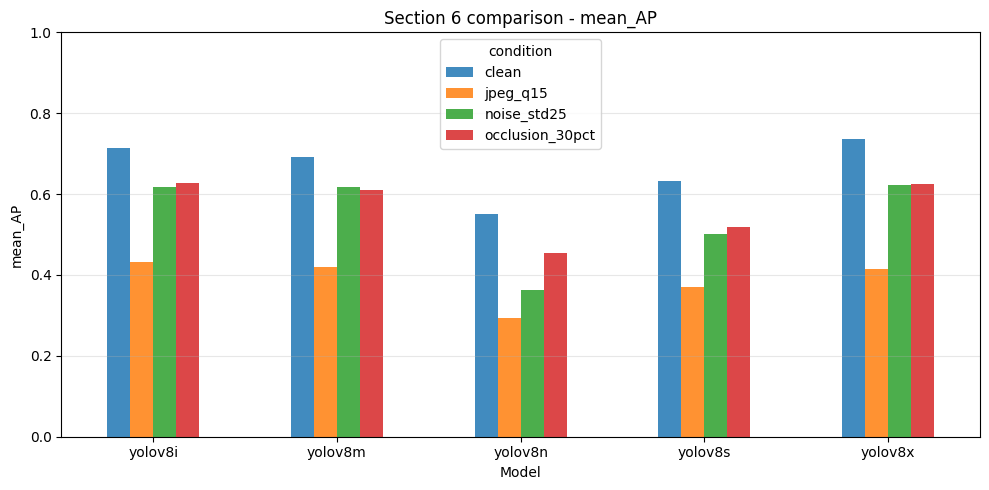

In [106]:
# Visual comparison across models and conditions
for metric in ["mAP@50", "mAP@50-95", "mean_AP"]:
    ax = df_section6_results.pivot(index="model", columns="condition", values=metric).plot(
        kind="bar", figsize=(10, 5), alpha=0.85
    )
    ax.set_title(f"Section 6 comparison - {metric}")
    ax.set_ylabel(metric)
    ax.set_xlabel("Model")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [107]:
# Robustness drop relative to clean for each model
df_clean_ref = df_section6_results[df_section6_results["condition"] == "clean"][
    ["model", "mAP@50", "mAP@50-95"]
].rename(columns={"mAP@50": "mAP@50_clean", "mAP@50-95": "mAP@50-95_clean"})

df_drop = df_section6_results[df_section6_results["condition"] != "clean"].merge(df_clean_ref, on="model", how="left")
df_drop["drop_mAP@50"] = df_drop["mAP@50_clean"] - df_drop["mAP@50"]
df_drop["drop_mAP@50-95"] = df_drop["mAP@50-95_clean"] - df_drop["mAP@50-95"]

df_drop = df_drop[[
    "model", "condition", "mAP@50", "mAP@50-95",
    "drop_mAP@50", "drop_mAP@50-95",
]].sort_values(["condition", "drop_mAP@50"], ascending=[True, True]).reset_index(drop=True)

df_drop

,model,condition,mAP@50,mAP@50-95,drop_mAP@50,drop_mAP@50-95
0,yolov8n,jpeg_q15,0.292737,0.215350,0.258944,0.200144
1,yolov8s,jpeg_q15,0.369768,0.259510,0.262870,0.222394
2,yolov8m,jpeg_q15,0.420075,0.300015,0.271462,0.250329
3,yolov8i,jpeg_q15,0.432937,0.314736,0.281680,0.263283
4,yolov8x,jpeg_q15,0.414823,0.287984,0.321099,0.304011
5,yolov8m,noise_std25,0.617006,0.472065,0.074531,0.078280
6,yolov8i,noise_std25,0.617248,0.480585,0.097369,0.097434
7,yolov8x,noise_std25,0.623644,0.479205,0.112278,0.112790
8,yolov8s,noise_std25,0.502093,0.369836,0.130546,0.112068
9,yolov8n,noise_std25,0.362162,0.264235,0.189519,0.151259


### 6.4 Repeat Section 5.4: robustness limits with growing distortion levels
This subsection evaluates each model under increasing distortion strength (noise/JPEG/occlusion) to identify robustness limits.

In [ ]:
# distortion levels
section6_noise_levels = [5, 15, 30, 50, 70]
section6_jpeg_levels = [70, 50, 30, 15, 5]
section6_occlusion_levels = [(0.15, 0.15), (0.30, 0.30), (0.45, 0.45), (0.60, 0.60), (0.75, 0.75)]

def section6_level_to_str(distortion_type, level):
    if distortion_type == 'noise':
        return f"std={level}"
    if distortion_type == 'jpeg':
        return f"q={level}"
    if distortion_type == 'occlusion':
        return f"{int(level[0] * 100)}%"
    return str(level)

In [ ]:
section6_limit_rows = []

for model_name, model_obj in section6_models.items():
    for std in section6_noise_levels:
        df_preds_local = section6_collect_predictions(
            model_obj, section6_img_ids, lambda im, s=std: add_gaussian_noise(im, mean=0, std=s)
        )
        _, df_metrics_main_local, map50_local, map50_95_local = section6_evaluate_predictions(df_preds_local)
        section6_limit_rows.append({
            'model': model_name,
            'distortion_type': 'noise',
            'distortion_level': section6_level_to_str('noise', std),
            'level_order': float(std),
            'mAP@50': float(map50_local),
            'mAP@50-95': float(map50_95_local),
            'mean_AP': float(df_metrics_main_local['AP'].mean()) if not df_metrics_main_local.empty else 0.0,
        })

    for q in section6_jpeg_levels:
        df_preds_local = section6_collect_predictions(
            model_obj, section6_img_ids, lambda im, qq=q: compress_image_jpeg(im, quality=qq)
        )
        _, df_metrics_main_local, map50_local, map50_95_local = section6_evaluate_predictions(df_preds_local)
        section6_limit_rows.append({
            'model': model_name,
            'distortion_type': 'jpeg',
            'distortion_level': section6_level_to_str('jpeg', q),
            'level_order': float(100 - q),
            'mAP@50': float(map50_local),
            'mAP@50-95': float(map50_95_local),
            'mean_AP': float(df_metrics_main_local['AP'].mean()) if not df_metrics_main_local.empty else 0.0,
        })

    for occ in section6_occlusion_levels:
        df_preds_local = section6_collect_predictions(
            model_obj, section6_img_ids, lambda im, ov=occ: apply_occlusion(im, ov)
        )
        _, df_metrics_main_local, map50_local, map50_95_local = section6_evaluate_predictions(df_preds_local)
        section6_limit_rows.append({
            'model': model_name,
            'distortion_type': 'occlusion',
            'distortion_level': section6_level_to_str('occlusion', occ),
            'level_order': float(occ[0]),
            'mAP@50': float(map50_local),
            'mAP@50-95': float(map50_95_local),
            'mean_AP': float(df_metrics_main_local['AP'].mean()) if not df_metrics_main_local.empty else 0.0,
        })

df_section6_limits = pd.DataFrame(section6_limit_rows)
df_section6_limits.sort_values(["distortion_type", "mean_AP"], inplace=True)

,model,distortion_type,distortion_level,level_order,mAP@50,mAP@50-95,mean_AP
0,yolov8n,noise,std=5,5.0,0.559641,0.420361,0.559641
1,yolov8n,noise,std=15,15.0,0.468885,0.344209,0.468885
2,yolov8n,noise,std=30,30.0,0.314842,0.227050,0.314842
3,yolov8n,noise,std=50,50.0,0.118336,0.080338,0.118336
4,yolov8n,noise,std=70,70.0,0.049830,0.029186,0.049830



Top models on noise by mean mAP@50 across levels


,mAP@50,mAP@50-95,mean_AP
model,,,
yolov8i,0.572135,0.444448,0.572135
yolov8x,0.567977,0.434434,0.567977
yolov8m,0.544694,0.420903,0.544694
yolov8s,0.410332,0.300555,0.410332
yolov8n,0.302307,0.220229,0.302307



Top models on jpeg by mean mAP@50 across levels


,mAP@50,mAP@50-95,mean_AP
model,,,
yolov8i,0.500738,0.385479,0.500738
yolov8x,0.495775,0.378341,0.495775
yolov8m,0.484475,0.368701,0.484475
yolov8s,0.441606,0.326830,0.441606
yolov8n,0.380401,0.281050,0.380401



Top models on occlusion by mean mAP@50 across levels


,mAP@50,mAP@50-95,mean_AP
model,,,
yolov8x,0.481792,0.367019,0.481792
yolov8i,0.453211,0.345274,0.453211
yolov8m,0.438700,0.326345,0.438700
yolov8s,0.363109,0.257902,0.363109
yolov8n,0.310079,0.218997,0.310079


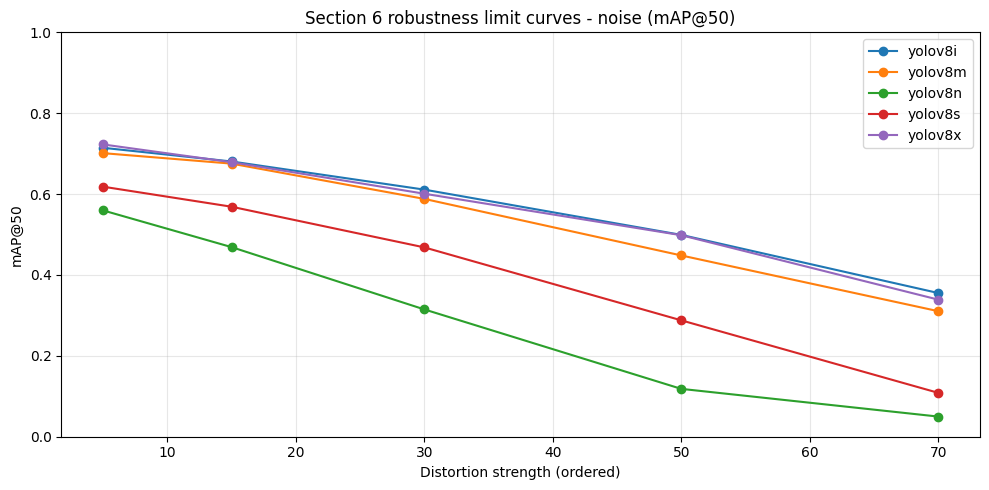

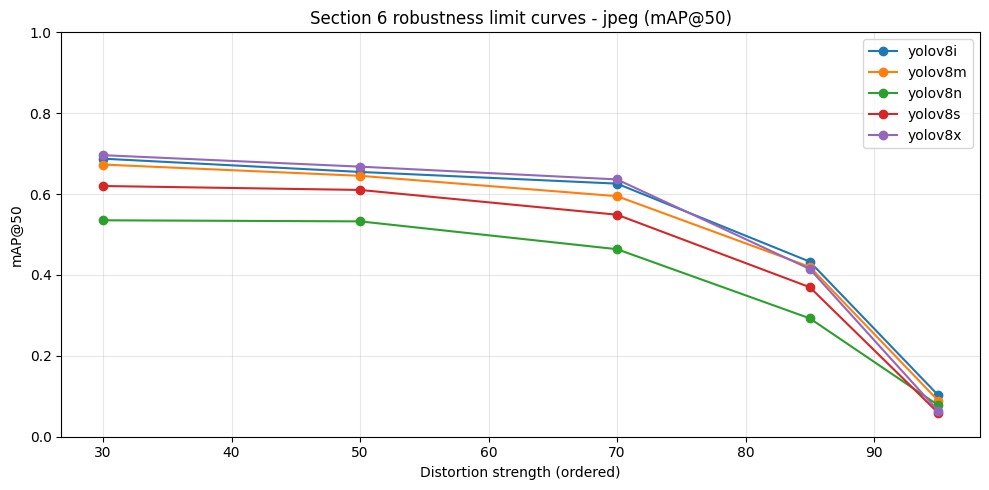

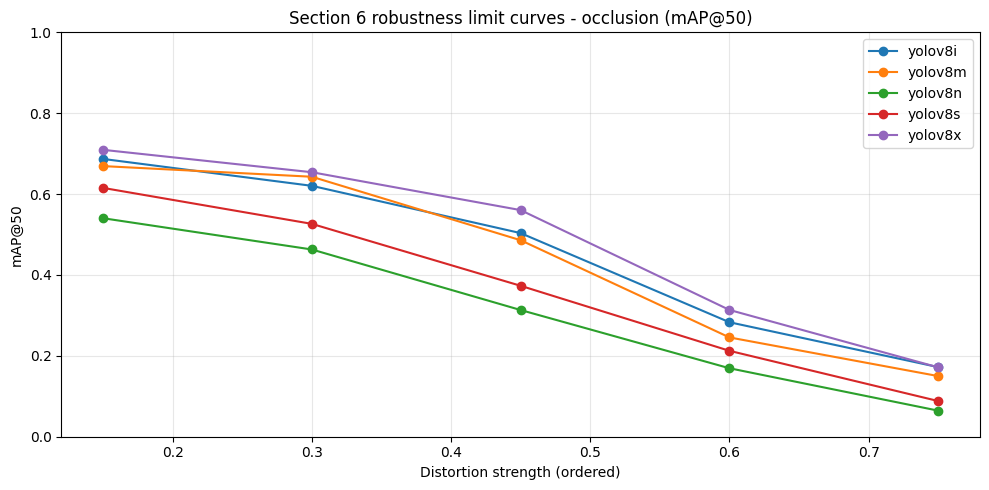

In [110]:
# Tables and plots for robustness limits
for distortion in ['noise', 'jpeg', 'occlusion']:
    print(f"\nTop models on {distortion} by mean mAP@50 across levels")
    display(
        df_section6_limits[df_section6_limits['distortion_type'] == distortion]
        .groupby('model')[['mAP@50', 'mAP@50-95', 'mean_AP']]
        .mean()
        .sort_values('mAP@50', ascending=False)
    )

for distortion in ['noise', 'jpeg', 'occlusion']:
    plt.figure(figsize=(10, 5))
    df_sub = df_section6_limits[df_section6_limits['distortion_type'] == distortion].sort_values('level_order')

    for model_name in sorted(df_sub['model'].unique()):
        df_m = df_sub[df_sub['model'] == model_name]
        plt.plot(df_m['level_order'], df_m['mAP@50'], marker='o', label=model_name)

    plt.title(f"Section 6 robustness limit curves - {distortion} (mAP@50)")
    plt.xlabel('Distortion strength (ordered)')
    plt.ylabel('mAP@50')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()